# S&P 500 options: features that are model outputs

Every column `03_financial_features` wrote is a rule fixed before the data was seen - a window, a
difference, a rank within a date. This notebook writes four columns that are not: two of them are
what a *fitted* volatility model says the next day's volatility will be, and two are the gap
between that forecast and the volatility the option market is charging for the same day.

Two models produce the forecasts, and both are estimated on a refit schedule: fitted on the
history available at a given session, held fixed for the month or quarter that follows, then
refitted on the history available then. No value is produced by parameters that had already seen
the session it describes.

The two models are:

1. **GJR-GARCH**, a variance recursion in which each day's variance is a weighted sum of
   yesterday's variance and yesterday's squared return, with an extra weight on the squared
   return when it was negative. Its five parameters are estimated by maximum likelihood.
2. **A stochastic-volatility model**, in which log-variance is itself a random walk that is never
   observed. Its single free parameter, the standard deviation of the random walk's steps, is
   estimated by Markov chain Monte Carlo; the unobserved daily volatility is then recovered by a
   particle filter.

**Learning objectives**. After working through this notebook you will be able to:

- Fit a volatility model on the history available at a point in time, run it forward over the
  dates that follow without re-estimating, and refit on a schedule - so that no value it produces
  was informed by the date it describes, on training dates as well as later ones.
- Recover a daily estimate of a quantity a model never observes, by carrying a population of
  candidate values forward one day at a time and reweighting them against each day's return.
- Write the difference between a model's volatility forecast and the option market's implied
  volatility as a feature, and say what a positive value of it would mean.
- Measure how far a fitted feature moves at the moment its parameters are replaced, and read off
  that comparison whether the refit cadence is buying anything.
- Test whether a feature ranks a cross-section against the outcome that was actually traded,
  correcting the test for the fact that consecutive positions overlap in time.

**Reads**: the straddle quote panel and the underlying daily bars from the loaders;
`features/financial.parquet` from [`03_financial_features`](03_financial_features.ipynb), for the
calendar the walk-forward split is cut on and as the reference the new columns are compared
against in section F; and the primary label from [`02_labels`](02_labels.ipynb), read only by
section F.

**Writes**: `features/model_based.parquet`, one row per date and symbol, and the small JSON file
recorded beside it. There is no `fold` column: what a value was fitted on is decided by the refit
schedule in `setup.yaml`, not by which fold reads it.

**Book reference**: Chapter 9, Section 9.3 (Volatility Models)

**Prerequisites**: [`02_labels`](02_labels.ipynb),
[`03_financial_features`](03_financial_features.ipynb)

In [1]:
"""S&P 500 options: model-based features from GJR-GARCH and a particle-filtered SV model."""

import hashlib
import logging
import warnings
from datetime import date, timedelta

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pymc as pm
import pytensor.tensor as pt
import yaml
from arch import arch_model
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

from case_studies.sp500_options._underlying_returns import reconcile_underlying_log_returns
from case_studies.utils.artifact_digest import read_digest, value_digest
from case_studies.utils.temporal import (
    garch11_conditional_volatility,
    refit_boundaries,
    walk_forward_feature,
    write_model_based,
)
from data import load_sp500_daily_bars, load_sp500_options_straddles
from utils.artifact_specs import resolve_label_buffer_unit
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.data_quality import top_entities
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, add_message_title, show_with_alt

warnings.filterwarnings("ignore")
logging.getLogger("pymc").setLevel(logging.ERROR)

## Configuration

Seven settings decide how much computation the stochastic-volatility half of the notebook does,
and each of them trades accuracy against time.

The Markov chain Monte Carlo step estimates one market-wide parameter, so it does not have to run
on every symbol: it runs on a pool of the ten symbols with the most quoted option dates inside the
training window, and the ten estimates are averaged. The pool size is what the step's cost is
linear in - ten fits per refit takes minutes, and every symbol would take days - and averaging over
ten stops any single company's volatility deciding the parameter. Each fit discards its first two
thousand draws while the sampler settles and keeps the next two thousand, on four chains started
from different points, because the only reliable evidence that a sampler has converged is that
separately started chains agree. The target acceptance rate makes the sampler take small, cautious
steps: this model's random-walk parameterization is badly enough conditioned that the sampler's
usual setting produces divergent transitions, which are steps it is known to have got wrong. The
retry settings are the second, longer attempt made for any symbol whose first fit fails the
convergence checks in section C.2.

The particle filter carries a thousand candidate values of the unobserved volatility forward
through each symbol's history. That count sets how finely the filter resolves the state: too few
and the estimate is noisy in a way that has nothing to do with the market.

The seed is threaded through every random draw. Section C.2 explains why it is combined with the
symbol rather than used directly.

In [2]:
SEED = 42
SV_POOL_SIZE = 10  # symbols the vol-of-vol parameter is estimated on, per refit
SV_N_PARTICLES = 1000  # candidate volatility states the particle filter carries
SV_DRAWS = 2000  # posterior draws kept per symbol
SV_TUNE = 2000  # draws discarded while the sampler adapts
SV_CHAINS = 4  # independently started chains
SV_TARGET_ACCEPT = 0.99  # step size target; higher means smaller, safer steps
SV_RETRY_DRAWS = 4000  # second attempt, for a symbol that fails the convergence checks
SV_RETRY_TUNE = 4000
# How often sigma_eta is re-estimated, in sessions. `None` means "use setup.yaml", which is
# what a production run does; the sibling knobs above reduce how expensive one sampler run is
# and this one reduces how many there are, which is the term that actually grew when this
# notebook moved from three per-fold passes to a schedule. A run that sets it is not a
# production run - it is not in `notebook_provenance.PRODUCTION_SAFE_PARAMETERS` - so a
# reduced render cannot be stamped as one.
SV_REFIT_EVERY_OVERRIDE = None
# Symbols to keep, most-observed first. 0 is a production run and reduces nothing. The knobs above
# make one sampler run cheaper and this one makes the panel smaller, which is the term a smoke run
# needs: without it a reduced run still fits GARCH on every symbol, so a preview of this notebook
# cost what the full run costs.
MAX_SYMBOLS = 0

In [3]:
CASE_DIR = get_case_study_dir("sp500_options")
FEATURES_DIR = CASE_DIR / "features"
LABELS_DIR = CASE_DIR / "labels"

STRATEGY_ID = "sp500_options"
set_global_seeds(SEED)

### What the models read

Two panels and one feature file. The straddle panel carries one end-of-session quote per symbol
per date for the at-the-money straddle nearest the target maturity, including the implied
volatility the two legs solve to; the daily bar panel carries the underlying's split- and
dividend-adjusted closes, which is what both models are fitted on. `financial.parquet` supplies
the calendar the walk-forward split is cut on - it has to be the same calendar the rest of the
case study uses - and in section F its columns are the reference the new ones are measured
against.

In [4]:
prices = load_sp500_options_straddles()
features = pl.read_parquet(FEATURES_DIR / "financial.parquet")
if MAX_SYMBOLS > 0:
    # Reduce on the universe that actually reaches the models, which is the intersection of the
    # straddle panel and the feature matrix - not on either one alone. Selecting from the straddle
    # panel by itself picks the most-quoted names in the whole options universe, and on a reduced
    # feature matrix most of them have no features: measured on the CI fixture, the 14 most-quoted
    # straddles include 7 of the 22 symbols stage 03 wrote, which is below the 10-symbol floor
    # section F's cross-sectional IC needs, so every date was skipped and the notebook raised.
    #
    # `top_entities` and its name tie-break are the same rule `05_evaluation` reduces by, so a
    # reduced 04 and a reduced 05 see one universe.
    common = pl.Series(sorted(set(prices["symbol"].unique()) & set(features["symbol"].unique())))
    kept_symbols = top_entities(
        prices.filter(pl.col("symbol").is_in(common)), MAX_SYMBOLS, entity_col="symbol"
    )
    prices = prices.filter(pl.col("symbol").is_in(kept_symbols))
    features = features.filter(pl.col("symbol").is_in(kept_symbols))
    print(
        f"Reduced run: {len(kept_symbols)} of {len(common)} symbols carrying both quotes and features"
    )
underlying = load_sp500_daily_bars(symbols=prices["symbol"].unique().sort().to_list())

print(f"Straddle quotes:  {prices.height:,} rows, {prices['symbol'].n_unique()} symbols")
print(f"Underlying bars:  {underlying.height:,} rows, {underlying['symbol'].n_unique()} symbols")
print(f"Feature calendar: {features['timestamp'].n_unique():,} sessions")

Straddle quotes:  361,010 rows, 627 symbols
Underlying bars:  631,926 rows, 627 symbols
Feature calendar: 1,238 sessions


### The walk-forward split

`generate_cv_splits` cuts the calendar into folds. Each fold has a training window the models are
estimated on and a validation window they are scored over, and consecutive folds are separated by
a gap wide enough that a position opened on the last training date has already closed before the
validation window starts. That gap is the label buffer declared in `setup.yaml`, set from how long
the straddle this case study sells runs before it expires. The holdout window is declared in the
same file and no fold reaches into it.

`hold_sessions` is how many NYSE sessions that expiry corresponds to. It appears twice below: it
annualizes a daily volatility, and it sets how far the standard errors in section F have to look
for the serial correlation that overlapping positions create.

In [5]:
_setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
_eval = load_evaluation_config(STRATEGY_ID)
holdout_start = str(_eval["holdout_start"])
holdout_end = str(_eval["holdout_end"])
label_buffer = str(_setup["labels"]["buffer"])
# What that buffer counts. `ret_to_expiry` resolves on an expiration date, so `setup.yaml`
# declares `labels.buffer_unit: calendar`; `generate_cv_splits` defaults to sessions, and a
# caller that does not pass the declaration silently gets fold boundaries that disagree with
# the ones `utils/modeling.py` fits on.
label_buffer_unit = resolve_label_buffer_unit(STRATEGY_ID, str(_setup["labels"]["primary"]), _setup)
LABEL_HORIZON_TRADING_DAYS = int(_setup["features"]["hold_sessions"])
PERIODS_PER_YEAR = int(_eval["periods_per_year"])
# The refit schedule. It is declared in setup.yaml rather than here because it is part of what
# the artifact is - two runs on different schedules produce different columns under the same
# name - and because `05_evaluation` onwards read the same file to say what they were given.
_schedule = _setup["model_based"]
GARCH_BURNIN = int(_schedule["garch"]["burnin"])
GARCH_REFIT_EVERY = int(_schedule["garch"]["refit_every"])
SV_BURNIN = int(_schedule["stochastic_volatility"]["burnin"])
SV_REFIT_EVERY = int(SV_REFIT_EVERY_OVERRIDE or _schedule["stochastic_volatility"]["refit_every"])
SV_CALIBRATION_WINDOW = int(_schedule["stochastic_volatility"]["calibration_window"])
# The GARCH specification, read rather than written here for the reason the schedule is. `o=1` is
# this case study's declared deviation from the shared GARCH(1,1)-Normal default; setup.yaml says
# what property of the underlying justifies it.
GARCH_KW = {k: _schedule["garch"][k] for k in ("mean", "vol", "p", "o", "q", "dist", "rescale")}
cv_folds = generate_cv_splits(
    features.select("timestamp"),
    case_study_id=STRATEGY_ID,
    label_buffer=label_buffer,
    buffer_unit=label_buffer_unit,
)
data_start = features["timestamp"].min()
holdout_train_end = (date.fromisoformat(holdout_start) - timedelta(days=1)).isoformat()

# The folds are read here for one purpose only: section F scores the new columns over the
# validation windows, which is where a fold still means something. Nothing in sections C to E
# uses them - what a value is fitted on is decided by the refit schedule, not by a fold - and
# `model_based.parquet` carries no fold column for the same reason.
print(f"Label buffer between training and validation: {label_buffer} ({label_buffer_unit})")
print(f"Holding period: {LABEL_HORIZON_TRADING_DAYS} NYSE sessions")
print(f"\nGARCH: {GARCH_BURNIN}-session burn-in, refit every {GARCH_REFIT_EVERY}")
print(
    f"SV:    {SV_BURNIN}-session burn-in, refit every {SV_REFIT_EVERY}, "
    f"calibrated on the trailing {SV_CALIBRATION_WINDOW}"
)
print(f"\nCross-validation folds, used by section F only: {len(cv_folds)}")
for fold in cv_folds:
    print(
        f"  Fold {fold['fold']}: train {fold['train_start'].date()}..{fold['train_end'].date()}, "
        f"validation {fold['val_start'].date()}..{fold['val_end'].date()}"
    )
print(f"  Holdout: {holdout_start}..{holdout_end}, no parameter estimated inside it")

Label buffer between training and validation: 35D (calendar)
Holding period: 21 NYSE sessions

GARCH: 252-session burn-in, refit every 21
SV:    252-session burn-in, refit every 63, calibrated on the trailing 252

Cross-validation folds, used by section F only: 2
  Fold 0: train 2017-02-02..2018-11-30, validation 2019-01-07..2020-01-03
  Fold 1: train 2018-01-05..2019-11-29, validation 2020-01-06..2020-11-25
  Holdout: 2021-01-01..2021-12-31, no parameter estimated inside it


One consequence of writing values across the holdout is easy to miss. Every summary this notebook
prints or draws - a mean, a spread, a median - would otherwise be computed over those rows too,
and a number computed over the holdout is a number read off it. The models may write there; the
notebook may not look.

The line is drawn where a number stops describing the shape of a file and starts describing what
is inside it. How many rows a panel holds, how many symbols it names and what dates it spans are
shape; they are fixed by the loaders and the fold windows, and they are shown whole because the
rest of the notebook cannot be followed without them. Anything computed from the values - a mean,
a spread, a median, a count of how often a column is empty, a per-period breakdown - goes through
the filter defined here.

In [6]:
HOLDOUT_START = date.fromisoformat(holdout_start)


def before_holdout(frame: pl.DataFrame) -> pl.DataFrame:
    """Return the rows dated before the holdout begins."""
    return frame.filter(pl.col("timestamp") < HOLDOUT_START)

### The universe the models are fitted across

It is not the same size throughout. S&P 500 membership turns over, options are listed and
delisted, and a symbol only appears on a date when a straddle near the target maturity was quoted
on it. Year by year below: how many sessions the year holds, how many symbols were quoted at
least once in it, the median number quoted on a single day, and the thinnest single day in it.

Those last two are what the cross-sectional test in section F rests on - a rank correlation is
only as informative as the number of names it ranks, and the thinnest day is what the minimum
that test accepts has to clear. The panel continues through the holdout year; its coverage is not
shown, for the reason given just above.

In [7]:
coverage_by_year = (
    before_holdout(prices)
    .group_by(["timestamp", pl.col("timestamp").dt.year().alias("year")])
    .agg(pl.col("symbol").n_unique().alias("quoted"))
    .group_by("year")
    .agg(
        pl.len().alias("sessions"),
        pl.col("quoted").median().round(0).cast(pl.Int64).alias("median_quoted_per_day"),
        pl.col("quoted").min().alias("thinnest_day"),
    )
    .join(
        before_holdout(prices)
        .group_by(pl.col("timestamp").dt.year().alias("year"))
        .agg(pl.col("symbol").n_unique().alias("symbols_in_year")),
        on="year",
    )
    .select("year", "sessions", "symbols_in_year", "median_quoted_per_day", "thinnest_day")
    .sort("year")
)
coverage_by_year

year,sessions,symbols_in_year,median_quoted_per_day,thinnest_day
i32,u32,u32,i64,u32
2017,251,527,212,173
2018,251,525,249,72
2019,252,524,252,226
2020,253,517,226,44


## A. Why a fitted feature is different

A feature in `03_financial_features` is a function of past prices: a twenty-one-session realized
volatility on 3 March uses the returns of the twenty-one sessions ending 3 March, and nothing
else. Whatever else is in the file cannot reach it.

A feature here is a function of past prices *and* of parameters that were themselves estimated
from prices. Two channels therefore carry data into the value, and both have to end at or before
the session it describes: the **conditioning set**, which observations the value is computed from,
and the **parameters**, which observations theta was estimated from. A conditional volatility for
3 March computed from parameters fitted on 2017-2021 looks exactly like one computed from
parameters fitted on 2017-2019. The first has read four years of the future; the second has not.

The recursion below closes the first channel, and this notebook always closed it. The second is
the one that was open. Parameters were estimated once per cross-validation fold on that fold's
whole training window, and the model was then run forward **from the start of that same window**.
A training row therefore carried parameters estimated from its own future - for the earliest rows
of a fold, years of it - while every validation row carried parameters estimated only from its
past. The model was fitted on one version of the column and scored on another. Nothing raised and
nothing could: a fold's rows are internally consistent, and the artifact recorded no estimation
window.

## B. The refit schedule

What replaces the fold is a schedule. A segment spends a burn-in during which it has no value at
all, is fitted on everything up to that point, and the parameters then speak for the next month
and no earlier session. At the next refit the fit is repeated on everything available then. So the
value at session $t$ is produced by parameters estimated from sessions ending at or before $t$,
for every $t$, with no exception for training rows.

The consequence for the file is that there are no passes. A session gets **one** conditional
volatility, not one per fold, and `model_based.parquet` carries one row per symbol and session
with no `fold` column. A fold selecting that session later reads the same value whichever fold it
is, which is what makes a column mean the same thing to a model trained across folds.

The schedule is declared in `setup.yaml` under `model_based:` and read at the top of this
notebook, because it is part of what the artifact *is*: two runs on different schedules produce
different columns under the same name.

The figure below is the whole claim in one line. For every session on the calendar, how recent
were the parameters that produced its value - drawn as the last session those parameters saw,
against the session itself. The staircase steps up at each refit and is flat in between, and it
stays below the diagonal everywhere, which is the property: no value was produced by a fit that
had seen it. The flat run at the right is the holdout, where the walk stops re-estimating and
keeps applying the last parameters fitted before the seal.

In [8]:
_calendar = sorted(features["timestamp"].unique().to_list())
# `freeze_after` is the largest **exclusive** fit end the walk may use, so it is the COUNT of
# sessions before the holdout and not the index of the last one. Passing the index would forbid
# the one fit that sees every pre-holdout session and nothing else - the best estimate available
# at the seal - and freeze on the refit before it instead, throwing away up to a month of
# perfectly usable history for no gain.
FREEZE_AFTER = next(
    (i for i, session in enumerate(_calendar) if session >= HOLDOUT_START), len(_calendar)
)

_blocks = refit_boundaries(len(_calendar), GARCH_BURNIN, GARCH_REFIT_EVERY)
_steps = []
# The first session of each block that carries NEW parameters. Not every emitted session,
# and not the first session of a frozen block either: a frozen block re-applies the estimate
# the block before it used, so nothing changes at its boundary and counting it as a refit
# would dilute the measurement in section D with sessions where no parameter moved.
_refit_sessions: list = []
_frozen_fit_end = None
for _fit_end, _emit_end in _blocks:
    if _fit_end > FREEZE_AFTER:
        if _frozen_fit_end is None:
            continue
        _effective = _frozen_fit_end
    else:
        _effective = _fit_end
        _frozen_fit_end = _fit_end
        _refit_sessions.append(_calendar[_fit_end])
    for _i in range(_fit_end, _emit_end):
        _steps.append((_calendar[_i], _calendar[_effective - 1]))

# The property, asserted rather than described: the last session a value's parameters saw is
# never later than the session the value is for.
assert _steps, "the refit schedule emits no session at all"
assert all(fit_end < session for session, fit_end in _steps), (
    "a session is described by parameters that had already seen it"
)
print(f"Calendar sessions: {len(_calendar):,}")
print(f"  Burn-in, no value on any segment: {GARCH_BURNIN}")
print(f"  Last session any parameter is fitted on: {_calendar[FREEZE_AFTER - 1]}")
print(f"  Refits before the holdout: {sum(1 for f, _ in _blocks if f <= (FREEZE_AFTER or 0))}")
print(f"  Sessions emitted: {len(_steps):,}")
# On the calendar. A segment refits on its OWN observations, so a segment that lists later
# than the panel starts reaches its first refit on a different date than this; the figure
# above draws the calendar schedule, and section D classifies per segment.
print(f"  Refits on the full calendar: {len(_refit_sessions):,}")

Calendar sessions: 1,238
  Burn-in, no value on any segment: 252
  Last session any parameter is fitted on: 2020-12-31
  Refits before the holdout: 35
  Sessions emitted: 986
  Refits on the full calendar: 35


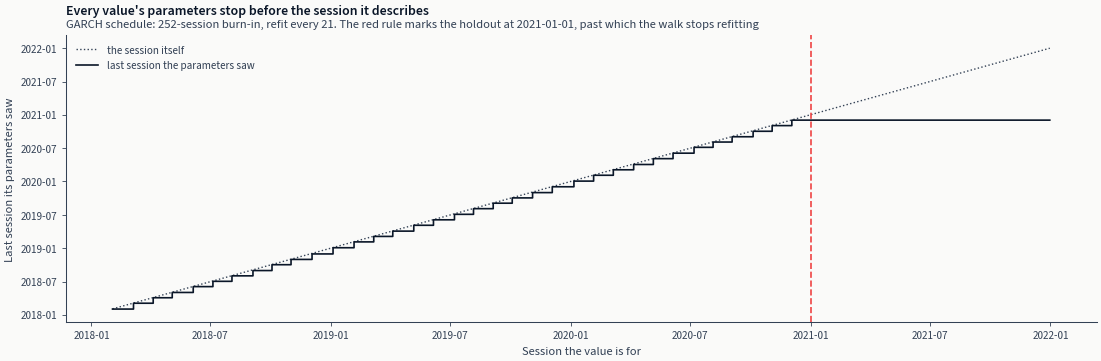

In [9]:
fig, ax = plt.subplots(figsize=(11, 3.6))
_x = [session for session, _ in _steps]
_y = [fit_end for _, fit_end in _steps]
ax.plot(_x, _x, color=COLORS["neutral"], linestyle=":", linewidth=1.0, label="the session itself")
ax.step(
    _x,
    _y,
    where="post",
    color=COLORS["blue"],
    linewidth=1.2,
    label="last session the parameters saw",
)
ax.axvline(HOLDOUT_START, color=COLORS["negative"], linestyle="--", linewidth=1.2)
ax.set(xlabel="Session the value is for", ylabel="Last session its parameters saw")
ax.legend(loc="upper left", frameon=False, fontsize=8)
add_message_title(
    ax,
    "Every value's parameters stop before the session it describes",
    subtitle=(
        f"GARCH schedule: {GARCH_BURNIN}-session burn-in, refit every {GARCH_REFIT_EVERY}. "
        f"The red rule marks the holdout at {holdout_start}, past which the walk stops refitting"
    ),
)
show_with_alt(
    fig,
    "Line chart whose horizontal axis is the session a feature value is for and whose vertical "
    "axis is the last session the parameters behind that value were estimated from. A dotted "
    "diagonal marks where the two would be equal. A blue staircase runs below that diagonal for "
    "the whole sample, stepping up at each monthly refit and flat in between, so the vertical "
    "gap between the two lines is the age of the parameters and is never negative. A dashed red "
    "vertical rule marks the start of the holdout, after which the staircase stops rising and "
    "runs flat to the end, showing that no parameter is re-estimated once the holdout opens.",
)

Values are written across the holdout, and that is deliberate: a later stage has to be able to
score a model over the holdout, and it cannot do that if the volatility columns are undefined
there. What makes it safe is the flat run in the figure - the parameters producing those values
were fitted before the seal, and nothing to the right of the red rule entered a fit.

### The returns both models read

Both models are fitted on the underlying's daily log returns, scaled by a hundred so that a
typical day is a number near one rather than a small fraction - the optimizer and the sampler
both behave better on that scale, and the scaling is undone before anything is written.

A ticker is not a company. A symbol can be reassigned after a delisting, and a company can be
reorganized under the same symbol, so the loader assigns a **security identity** - the `sec_id`
column - that changes when the series behind the ticker changes. A return spanning such a change
is an artefact of the reassignment rather than a move anyone experienced, so those returns are
dropped, and every model below is fitted on one **(symbol, security identity)** pair at a time.
Nothing - a return, a set of fitted parameters, a filtered volatility state - crosses from one
such pair to another. For brevity the rest of the notebook calls one of these pairs a *segment*.

A segment needs at least a hundred returns before either model is worth fitting on it.

In [10]:
reconciled_returns = reconcile_underlying_log_returns(underlying)
identity_boundaries = reconciled_returns.filter(pl.col("identity_boundary"))

returns_df = (
    reconciled_returns.with_columns((pl.col("clean_log_return") * 100).alias("log_ret_pct"))
    .filter(pl.col("log_ret_pct").is_not_null())
    .select(["timestamp", "symbol", "sec_id", "log_ret_pct"])
)

print(f"Returns: {returns_df.height:,} rows, {returns_df['symbol'].n_unique()} symbols")
print(f"Returns spanning a security identity change, dropped: {identity_boundaries.height:,}")

Returns: 631,272 rows, 627 symbols
Returns spanning a security identity change, dropped: 15


In [11]:
segment_returns: dict[tuple[str, int], pd.Series] = {}
for segment in returns_df.partition_by(["symbol", "sec_id"], maintain_order=True):
    symbol = segment["symbol"].item(0)
    sec_id = int(segment["sec_id"].item(0))
    segment_pd = segment.sort("timestamp").to_pandas().set_index("timestamp")
    if len(segment_pd) >= 100:
        segment_returns[(symbol, sec_id)] = segment_pd["log_ret_pct"]

print(
    f"Segments with at least 100 returns: {len(segment_returns)} "
    f"across {len({key[0] for key in segment_returns})} symbols"
)

Segments with at least 100 returns: 620 across 609 symbols


## C. One section per model

### C.1 GJR-GARCH

GARCH models write today's variance as a weighted sum of yesterday's variance and yesterday's
squared return. The GJR variant (Glosten, Jagannathan and Runkle 1993) adds a third term that
fires only when yesterday's return was negative:

$$h_t = \omega + \alpha \varepsilon_{t-1}^2 + \gamma \varepsilon_{t-1}^2 \mathbf{1}[\varepsilon_{t-1} < 0] + \beta h_{t-1}$$

That extra term is there because a fall of a given size raises subsequent volatility more than a
rise of the same size does - the asymmetry equity index options are priced around, and the reason
a symmetric GARCH understates volatility exactly when a short-volatility position is losing.

Four parameters plus a constant mean are estimated by maximum likelihood on the returns available
at a refit. The recursion is then run forward with those parameters held fixed, one day at a time,
each day reading only the previous day's variance and squared return, until the next refit
replaces them. A segment is fitted once every twenty-one sessions on everything it has by then,
never on a window that reaches past the sessions the fit will speak for.

The recursion is run by `garch11_conditional_volatility` rather than by the fitting library, and
the reason is worth stating because it is the kind of leak a code review does not catch. Handing
a fitted result back to `arch` and asking it to filter a longer series makes it recompute the
bounds it clips the variance path to, and it computes them from the residuals of the series it
was handed - which now includes the later dates. The clipping envelope would then depend on the
future. Everything the recursion needs - the scale, the value it starts from, the clipping
bounds - is derived from the training returns alone and passed in.

The fit itself. Maximum likelihood on a variance recursion is a hard optimization and the
optimizer sometimes stops without converging; when it does, it is restarted from where it stopped
with a tighter tolerance rather than from a random point, so the second attempt is reproducible
and the first attempt's progress is not thrown away. A segment that still does not converge is
recorded and excluded, never used.

In [12]:
def fit_garch_with_retry(train_returns: pd.Series):
    """Fit GJR-GARCH once, then retry a nonconverged optimizer deterministically."""
    model = arch_model(train_returns, **GARCH_KW)
    result = model.fit(disp="off", show_warning=False)
    retried = result.convergence_flag != 0
    if retried:
        result = model.fit(
            starting_values=result.params.to_numpy(),
            disp="off",
            show_warning=False,
            tol=1e-9,
            options={"maxiter": 2_000, "ftol": 1e-9},
        )
    return result, retried

In [13]:
def summarize_garch_fit(result, train_returns: pd.Series, retried: bool) -> dict:
    """Create one complete diagnostic record for an optimizer result."""
    persistence = (
        result.params.get("alpha[1]", 0)
        + result.params.get("beta[1]", 0)
        + result.params.get("gamma[1]", 0) / 2
    )
    return {
        "converged": result.convergence_flag == 0,
        "retried": retried,
        "convergence_flag": int(result.convergence_flag),
        "persistence": float(persistence),
        "log_likelihood": float(result.loglikelihood),
        "fit_start": train_returns.index.min(),
        "fit_end": train_returns.index.max(),
        "n_fit": len(train_returns),
        "error_type": None,
        "error_message": None,
    }

This is the cell the section opened with. Three quantities the recursion needs are not parameters
and are easy to forget: the scale the fitting library chose, the value the variance series starts
from before there is any history to compute it from, and the bounds the variance is clipped to.
All three are derived here from the training residuals alone and then passed forward unchanged,
which is what keeps the forward pass a function of the training window.

In [14]:
def training_garch_filter_state(result, train_returns: pd.Series) -> tuple[float, float, tuple]:
    """Derive scale, initialization, and static bounds from training data only."""
    fit_scale = float(result.model.scale)
    mu = float(result.params.get("mu", result.params.get("Const", 0.0)))
    train_residuals = train_returns.to_numpy(dtype=float) * fit_scale - mu
    backcast = float(result.model.volatility.backcast(train_residuals))
    train_bounds = result.model.volatility.variance_bounds(train_residuals)
    static_bounds = (
        float(train_bounds[:, 0].min()),
        float(train_bounds[:, 1].max()),
    )
    return fit_scale, backcast, static_bounds

In [15]:
def failed_garch_diagnostic(train_returns: pd.Series, retried: bool, exc: Exception) -> dict:
    """Create a denominator-preserving diagnostic for an eligible errored fit."""
    return {
        "converged": False,
        "retried": retried,
        "convergence_flag": None,
        "persistence": None,
        "log_likelihood": None,
        "fit_start": train_returns.index.min(),
        "fit_end": train_returns.index.max(),
        "n_fit": len(train_returns),
        "error_type": type(exc).__name__,
        "error_message": str(exc),
    }

The four above assemble into one walk. `walk_forward_feature` spends the burn-in, fits on
everything up to the first refit session, emits over the month that follows, refits on everything
up to the next one, and carries on to the end of the segment. `fit` is handed the training prefix
and returns the five parameters plus the three quantities the recursion needs that are not
parameters; `apply` is handed the fitted object and a prefix of returns and filters over it, of
which only the current block's rows are kept.

Two things about it are worth stating because they are what make the walk causal rather than
merely walk-shaped. The estimation window expands, so a fit's last observation is at index
`len(train) - 1` of the segment - which is what the diagnostic record below writes down as
`fit_end`, and what section B asserts is never later than the session it speaks for. And
`freeze_after` stops the re-estimation at the last session before the holdout: the holdout still
receives values, produced by the last parameters fitted before it opened, because a coefficient
refitted on holdout sessions is a parameter estimated on the holdout however causal the recursion
around it looks.

A block whose optimizer does not converge is left empty rather than filled with the previous
month's parameters, and it is counted. The record is written before the rejection is raised, so a
segment that drops out of a block stays in the denominator.

In [16]:
class GarchBlockRejected(RuntimeError):
    """Raised for an optimizer result that must not be used to emit a block."""


def garch_walk_segment(
    ret_series: pd.Series,
    burnin: int,
    refit_every: int,
    freeze_after: int | None,
) -> tuple[pd.Series, list[dict]]:
    """Filter one segment on the refit schedule, returning values and one record per fit."""
    diagnostics: list[dict] = []
    observations = ret_series.to_numpy(dtype=float).reshape(-1, 1)

    def fit(train: np.ndarray) -> dict:
        # The walk expands, so the training prefix always starts at the segment's first
        # return and its length is the index one past the last session the fit could see.
        train_returns = ret_series.iloc[: len(train)]
        try:
            result, retried = fit_garch_with_retry(train_returns)
        except Exception as exc:
            # Recorded before it is re-raised, so a block whose optimizer errored stays in
            # the denominator instead of disappearing from it. `walk_forward_feature` will
            # leave the block null and refit at the next boundary.
            failure = failed_garch_diagnostic(train_returns, False, exc)
            failure["emit_start"] = ret_series.index[len(train)]
            diagnostics.append(failure)
            raise
        record = summarize_garch_fit(result, train_returns, retried)
        # The first session this fit speaks for. The walk schedules on the segment's own
        # observations, so it is not `calendar[fit_end]`: a segment that starts later, or
        # that is missing sessions the calendar has, refits on different dates than its
        # neighbours. Section D classifies moves by this, per segment, for that reason.
        record["emit_start"] = ret_series.index[len(train)]
        if not record["converged"]:
            diagnostics.append(record)
            raise GarchBlockRejected(f"optimizer flag {record['convergence_flag']}")
        fit_scale, backcast, static_bounds = training_garch_filter_state(result, train_returns)
        record.update(
            {
                "fit_scale": fit_scale,
                "backcast": backcast,
                "variance_lower_bound": static_bounds[0],
                "variance_upper_bound": static_bounds[1],
            }
        )
        diagnostics.append(record)
        return {
            "mu": float(result.params.get("mu", result.params.get("Const", 0.0))),
            "omega": float(result.params["omega"]),
            "alpha": float(result.params["alpha[1]"]),
            "gamma": float(result.params["gamma[1]"]),
            "beta": float(result.params["beta[1]"]),
            "scale": fit_scale,
            "backcast": backcast,
            "bounds": static_bounds,
        }

    def apply(model: dict, prefix: np.ndarray) -> np.ndarray:
        # `arch` estimates on returns it has scaled, so mu, omega and the bounds are all in the
        # scaled units and the recursion has to run there too. Dividing by the same factor
        # returns the volatility to percent, and the annualization follows.
        scale = model["scale"]
        sigma = (
            garch11_conditional_volatility(
                prefix[:, 0] * scale,
                mu=model["mu"],
                omega=model["omega"],
                alpha=model["alpha"],
                gamma=model["gamma"],
                beta=model["beta"],
                backcast=model["backcast"],
                bounds=model["bounds"],
            )
            / scale
        )
        return (sigma / 100 * np.sqrt(PERIODS_PER_YEAR)).reshape(-1, 1)

    values = walk_forward_feature(
        observations,
        timestamps=ret_series.index.to_numpy(),
        burnin=burnin,
        refit_every=refit_every,
        fit=fit,
        apply=apply,
        n_features=1,
        window=None,
        freeze_after=freeze_after,
        on_fit_error="skip",
    )
    return pd.Series(values[:, 0], index=ret_series.index), diagnostics

The walk runs once per segment over that segment's whole history. There are no passes any more:
a session gets one conditional volatility, from the last parameters fitted before it, and a fold
selecting that session later reads the same value whichever fold it is.

A segment shorter than the burn-in produces nothing and is counted. That is a statement about the
segment rather than an error - a symbol listed eighteen months before the panel ends cannot
support a fitted volatility model over most of its life - and the coverage report below is where
it is read.

In [17]:
def count_before(index: pd.Index, boundary: pd.Timestamp) -> int:
    """How many entries fall strictly before *boundary*.

    This is what ``walk_forward_feature`` wants for ``freeze_after``: the largest exclusive
    fit end it may use, so that the last estimate before the seal is fitted on every session
    before it and on no session after.
    """
    return int(index.searchsorted(boundary, side="left"))

In [18]:
garch_results = []
garch_diagnostics = []
garch_short = 0

for (symbol, sec_id), ret_series in segment_returns.items():
    freeze_after = count_before(ret_series.index, pd.Timestamp(HOLDOUT_START))
    cond_vol, segment_diagnostics = garch_walk_segment(
        ret_series,
        burnin=GARCH_BURNIN,
        refit_every=GARCH_REFIT_EVERY,
        freeze_after=freeze_after,
    )
    for record in segment_diagnostics:
        garch_diagnostics.append({"symbol": symbol, "sec_id": sec_id, **record})
    emitted = cond_vol.dropna()
    if emitted.empty:
        garch_short += 1
        continue
    garch_results.append(
        pl.DataFrame(
            {
                "timestamp": emitted.index.values,
                "symbol": symbol,
                "sec_id": sec_id,
                "garch_cond_vol": emitted.values,
            }
        )
    )

print(f"Segments emitting a GARCH value: {len(garch_results)} of {len(segment_returns)}")
print(f"  Segments that never clear the {GARCH_BURNIN}-session burn-in: {garch_short}")
print(f"  Fits attempted across every segment and refit: {len(garch_diagnostics):,}")

Segments emitting a GARCH value: 563 of 620
  Segments that never clear the 252-session burn-in: 57
  Fits attempted across every segment and refit: 17,104


In [19]:
def validate_segment_feature_panel(frame: pl.DataFrame, value_col: str) -> None:
    """Validate identity provenance, output uniqueness, and numeric coverage."""
    if frame.is_empty():
        raise RuntimeError(f"No {value_col} features were generated")

    key_cols = ["timestamp", "symbol"]
    duplicate_keys = int(frame.select(key_cols).is_duplicated().sum())
    if duplicate_keys:
        raise RuntimeError(f"{value_col} contains {duplicate_keys} duplicate output keys")

    identity_cols = ["timestamp", "symbol", "sec_id"]
    valid_identities = returns_df.select(identity_cols).unique()
    unknown_identities = (
        frame.select(identity_cols).unique().join(valid_identities, on=identity_cols, how="anti")
    )
    if not unknown_identities.is_empty():
        raise RuntimeError(
            f"{value_col} contains {unknown_identities.height} rows outside its security segment"
        )

    invalid_values = frame.filter(pl.col(value_col).is_null() | ~pl.col(value_col).is_finite())
    if not invalid_values.is_empty():
        raise RuntimeError(f"{value_col} contains {invalid_values.height} invalid values")

    print(
        f"  Coverage guard: {frame.select(['symbol', 'sec_id']).unique().height} "
        f"segments, {frame['symbol'].n_unique()} symbols, unique output keys"
    )

In [20]:
if not garch_results:
    raise RuntimeError("No GARCH fit produced a feature panel")
garch_df = pl.concat(garch_results).with_columns(pl.col("timestamp").cast(pl.Date))
validate_segment_feature_panel(garch_df, "garch_cond_vol")
print(f"\nGARCH panel: {garch_df.height:,} rows, {garch_df['symbol'].n_unique()} symbols")
print(f"  Date range: {garch_df['timestamp'].min()} to {garch_df['timestamp'].max()}")
print(
    "  Mean annualized conditional volatility before the holdout: "
    f"{before_holdout(garch_df)['garch_cond_vol'].mean():.4f}"
)

  Coverage guard: 563 segments, 558 symbols, unique output keys

GARCH panel: 473,786 rows, 558 symbols
  Date range: 2018-01-04 to 2021-12-31
  Mean annualized conditional volatility before the holdout: 0.3006


#### What the burn-in costs this panel

The burn-in is not free and on this case study it is not cheap. The calendar runs to 1,238
sessions but a symbol only appears on it while a straddle near the target maturity was quoted on
its underlying, so the median segment is far shorter than the calendar and the shortest are
shorter than the burn-in itself. A segment that never reaches 252 returns produces no GARCH value
at all, and one that reaches it late produces values only for the part of its life after that.

The two numbers below are the ones to read before using this column: how many segments clear the
burn-in, and what share of the sessions on which the underlying actually traded carry a value.
Both are taken before the holdout, like every other measurement here. A low second number is a
statement about what a fitted per-symbol volatility model can do on a panel of this shape, not a
parameter to tune until it looks better - 252 is already the shortest burn-in that leaves a GJR
recursion's leverage term anything to estimate from.

In [21]:
_eligible = before_holdout(returns_df).select(["timestamp", "symbol", "sec_id"])
_covered = before_holdout(garch_df).select(["timestamp", "symbol", "sec_id"])
_segment_lengths = (
    _eligible.group_by(["symbol", "sec_id"]).agg(pl.len().alias("n")).sort("n", descending=True)
)
coverage = {
    "segments_eligible": _segment_lengths.height,
    "segments_with_a_value": _covered.select(["symbol", "sec_id"]).unique().height,
    "rows_eligible": _eligible.height,
    "rows_with_a_value": _covered.height,
    "median_segment_sessions": int(_segment_lengths["n"].median()),
    "p10_segment_sessions": int(_segment_lengths["n"].quantile(0.10)),
}
print(
    f"Segments clearing the {GARCH_BURNIN}-session burn-in: "
    f"{coverage['segments_with_a_value']} of {coverage['segments_eligible']} "
    f"({coverage['segments_with_a_value'] / coverage['segments_eligible']:.1%})"
)
print(
    f"Sessions carrying a GARCH value: {coverage['rows_with_a_value']:,} of "
    f"{coverage['rows_eligible']:,} ({coverage['rows_with_a_value'] / coverage['rows_eligible']:.1%})"
)
print(
    f"Segment length before the holdout: median {coverage['median_segment_sessions']} sessions, "
    f"tenth percentile {coverage['p10_segment_sessions']}"
)

Segments clearing the 252-session burn-in: 563 of 618 (91.1%)
Sessions carrying a GARCH value: 355,875 of 505,066 (70.5%)
Segment length before the holdout: median 1006 sessions, tenth percentile 279


### Figure F2. One series per symbol, and where it starts

Under the old design this figure drew one line per fold, because a date covered by two folds
carried two conditional volatilities for the same symbol - the same returns read through two
different parameter sets, and the vertical distance between the lines was the size of the problem
this notebook now does not have. There is one line now, because there is one value.

What is worth drawing instead is where the line begins. The symbol with the longest history is
drawn against the one at the median length, on the same axes: the first starts shortly after the
burn-in and runs the width of the sample, the second starts far later and is the shape most of
the cross-section has. The dotted rule marks the first session any segment can carry a value.

The lines stop at the holdout. Values are written past it, and no summary in this notebook reads
them.

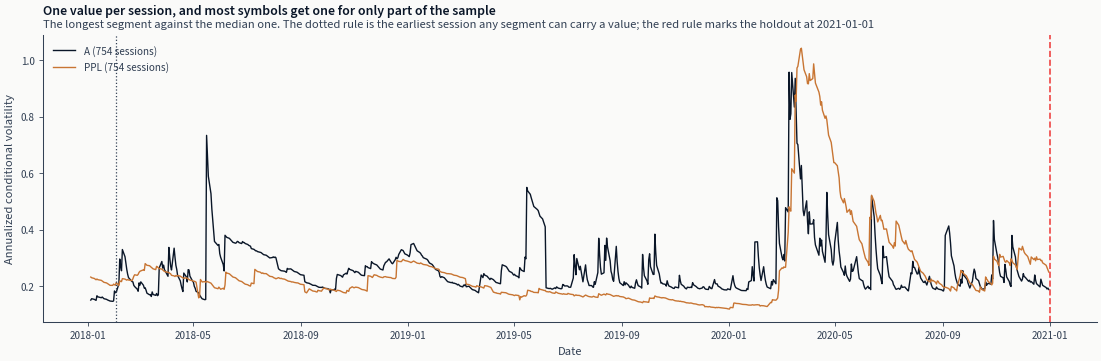

In [22]:
_drawn = before_holdout(garch_df)
_lengths = _drawn.group_by("symbol").len().sort(["len", "symbol"], descending=[True, False])
_longest = _lengths["symbol"][0]
_median = _lengths["symbol"][_lengths.height // 2]
fig, ax = plt.subplots(figsize=(11, 3.6))
for _symbol, _color in ((_longest, COLORS["blue"]), (_median, COLORS["copper"])):
    _path = _drawn.filter(pl.col("symbol") == _symbol).sort("timestamp")
    ax.plot(
        _path["timestamp"].to_list(),
        _path["garch_cond_vol"].to_list(),
        color=_color,
        linewidth=1.0,
        label=f"{_symbol} ({_path.height} sessions)",
    )
ax.axvline(_calendar[GARCH_BURNIN], color=COLORS["neutral"], linestyle=":", linewidth=0.9)
ax.axvline(HOLDOUT_START, color=COLORS["negative"], linestyle="--", linewidth=1.2)
ax.set(xlabel="Date", ylabel="Annualized conditional volatility")
ax.legend(loc="upper left", frameon=False, fontsize=8)
add_message_title(
    ax,
    "One value per session, and most symbols get one for only part of the sample",
    subtitle=(
        "The longest segment against the median one. The dotted rule is the earliest session any "
        f"segment can carry a value; the red rule marks the holdout at {holdout_start}"
    ),
)
show_with_alt(
    fig,
    "Line chart of annualized conditional volatility against date for two symbols, the one with "
    "the longest history and the one at the median length. Each symbol is drawn as a single "
    "continuous line rather than one line per fold, because every session now carries exactly "
    "one value. The longer series begins shortly after a dotted vertical rule marking the end of "
    "the burn-in and runs the width of the chart; the median-length series begins much later and "
    "covers only the right-hand part of it, which is the shape most of the cross-section has. "
    "Both are spiky, sitting near 0.2 for long stretches with sharp excursions above 1.0, the "
    "largest clustered around March 2020. A dashed red rule marks the holdout, which neither "
    "line crosses.",
)

### C.2 Stochastic volatility

GARCH makes yesterday's return determine today's variance exactly. A stochastic-volatility model
drops that: log-variance follows its own random walk, which nothing observes directly, and the
return is drawn around it.

$$h_{t} = h_{t-1} + \eta_t, \quad \eta_t \sim \mathcal{N}(0, \sigma_\eta^2)$$
$$r_t \sim \mathcal{N}(0, \exp(h_t))$$

The one free parameter, $\sigma_\eta$, says how far the volatility level is allowed to drift from
one day to the next. Small values give a volatility that changes slowly; large values let it jump
to accommodate a single big return.

The model costs more than GARCH in two ways, and both shape what follows. Its likelihood has no
closed form, because every unobserved $h_t$ has to be integrated out, so $\sigma_\eta$ is
estimated by drawing from the posterior with Markov chain Monte Carlo rather than by maximizing
anything. And once $\sigma_\eta$ is fixed, recovering the daily $h_t$ needs a second algorithm:
a particle filter, which carries a population of candidate values forward and reweights them
against each day's return.

The split follows the same discipline as GARCH. $\sigma_\eta$ is a property of how equity
volatility behaves rather than of any one company, so it is estimated once per refit on a small
pool of symbols and then held fixed while every segment is filtered over the sessions that refit
speaks for.

#### Which symbols the parameter is estimated on

The pool is chosen by option coverage *inside the calibration window* - the symbols with the most
dates carrying a straddle quote in the year ending at the refit - and not by coverage over the
whole sample. Choosing on whole-sample coverage would be a leak of exactly the kind this notebook
is about: which symbols stayed liquid afterwards is information from afterwards.

In [23]:
def option_coverage_in_window(
    option_panel: pl.DataFrame,
    identity_panel: pl.DataFrame,
    start_date: date,
    end_date: date,
) -> pl.DataFrame:
    """Count observed option dates per identity inside one training window."""
    in_training = pl.col("timestamp").is_between(start_date, end_date, closed="both")
    return (
        option_panel.filter(in_training)
        .select(["timestamp", "symbol"])
        .unique()
        .join(
            identity_panel.select(["timestamp", "symbol", "sec_id"]).unique(),
            on=["timestamp", "symbol"],
            how="inner",
        )
        .group_by(["symbol", "sec_id"])
        .agg(pl.len().alias("n_option_days"))
    )

In [24]:
def return_coverage_in_window(
    return_panel: pl.DataFrame, start_date: date, end_date: date
) -> pl.DataFrame:
    """Count eligible return observations per identity inside a training window."""
    return (
        return_panel.filter(pl.col("timestamp").is_between(start_date, end_date, closed="both"))
        .group_by(["symbol", "sec_id"])
        .agg(pl.len().alias("n_return_days"))
        .filter(pl.col("n_return_days") >= 252)
    )

In [25]:
def select_sv_pool(
    option_panel: pl.DataFrame,
    identity_panel: pl.DataFrame,
    return_panel: pl.DataFrame,
    train_start: date,
    train_end: date,
    pool_size: int,
) -> list[tuple[str, int]]:
    """Select segments by training-window option coverage and return eligibility."""
    start_date, end_date = pd.Timestamp(train_start).date(), pd.Timestamp(train_end).date()
    option_coverage = option_coverage_in_window(option_panel, identity_panel, start_date, end_date)
    return_coverage = return_coverage_in_window(return_panel, start_date, end_date)
    selected = (
        option_coverage.join(return_coverage, on=["symbol", "sec_id"], how="inner")
        .sort(
            ["n_option_days", "n_return_days", "symbol", "sec_id"],
            descending=[True, True, False, False],
        )
        .head(pool_size)
    )
    if selected.height < pool_size:
        raise RuntimeError(
            f"Only {selected.height} security segments have 252 training observations"
        )
    return [(row["symbol"], int(row["sec_id"])) for row in selected.iter_rows(named=True)]

Both the sampler and the filter need random numbers, and the obvious way to supply them - one
generator advanced through the loop - makes every segment's result depend on how many segments
came before it. Adding one symbol to the universe would then change the filtered path of every
symbol after it in the loop, and none of those changes would be visible in a diff. Deriving each
stream's seed from the segment's own identity removes the dependence: a segment's numbers are the
same whatever else is in the run.

In [26]:
def stable_segment_seed(base_seed: int, namespace: str, symbol: str, sec_id: int) -> int:
    """Derive a stable unsigned 32-bit seed from model and security identity."""
    payload = f"{base_seed}|{namespace}|{symbol}|{sec_id}".encode()
    return int.from_bytes(hashlib.blake2s(payload, digest_size=4).digest(), "big")

#### Estimating the parameter

Each pool symbol contributes the calibration window's returns, and the
sampler returns a posterior distribution for $\sigma_\eta$ rather than a point. The estimate the
filter uses is the mean of each symbol's posterior mean, weighted equally, so that a symbol whose
second, longer attempt produced more draws does not count for more than one that converged first
time.

A Monte Carlo sampler can return draws even when it has not converged, and they look like
ordinary draws. Four checks decide whether a symbol's posterior is used at all, and a symbol that
fails them after one longer retry stops the notebook rather than being quietly dropped:

- **R-hat** compares the variance between chains with the variance within them. It equals one
  when the chains are exploring the same distribution, and the gate below rejects anything
  meaningfully above that.
- **Effective sample size**, in the bulk and in the tails of the posterior. Consecutive draws are
  correlated, so two thousand draws are worth fewer than two thousand independent ones; the gate
  asks for at least four hundred independent-equivalent draws before it trusts a posterior mean.
- **Divergences** are steps the sampler's integrator is known to have got wrong. Any at all mean
  part of the posterior was never visited.
- **Maximum tree depth hits** mean the sampler ran out of allowed steps before it finished a
  trajectory, which makes the draws it did take unrepresentative.

In [27]:
def fit_sv_calibration_symbol(
    train_returns: np.ndarray,
    n_draws: int,
    n_tune: int,
    n_chains: int,
    seed: int,
) -> tuple[np.ndarray, dict[str, float]]:
    """Sample one security segment's SV calibration posterior and diagnostics."""
    with pm.Model():
        sigma_eta = pm.Exponential("sigma_eta", lam=2)
        h0 = pm.Normal("h0", mu=0, sigma=1)
        innovations = pm.Normal("innovations", mu=0, sigma=1, shape=len(train_returns) - 1)
        h = pm.Deterministic(
            "h",
            pt.concatenate([h0[None], h0 + sigma_eta * pt.cumsum(innovations)]),
        )
        volatility = pm.Deterministic("volatility", pm.math.exp(h / 2))
        pm.Normal("obs", mu=0, sigma=volatility, observed=train_returns)
        trace = pm.sample(
            n_draws,
            tune=n_tune,
            chains=n_chains,
            cores=n_chains,
            progressbar=False,
            random_seed=seed,
            target_accept=SV_TARGET_ACCEPT,
        )

    return trace.posterior["sigma_eta"].values.flatten(), summarize_sv_trace(trace)

In [28]:
def summarize_sv_trace(trace) -> dict[str, float]:
    """Extract every hard-gate diagnostic from one accepted trace candidate."""
    sample_stats = trace.sample_stats
    if "reached_max_treedepth" in sample_stats:
        max_treedepth_hits = int(sample_stats["reached_max_treedepth"].values.sum())
    else:
        max_treedepth_hits = int((sample_stats["tree_depth"].values >= 10).sum())
    return {
        "rhat": float(az.rhat(trace, var_names=["sigma_eta"], method="rank")["sigma_eta"].item()),
        "ess_bulk": float(
            az.ess(trace, var_names=["sigma_eta"], method="bulk")["sigma_eta"].item()
        ),
        "ess_tail": float(
            az.ess(trace, var_names=["sigma_eta"], method="tail")["sigma_eta"].item()
        ),
        "divergences": int(sample_stats["diverging"].values.sum()),
        "max_treedepth_hits": max_treedepth_hits,
    }

In [29]:
def sv_diagnostics_pass(diagnostics: dict[str, float]) -> bool:
    """Return whether one SV posterior clears every hard calibration gate."""
    return bool(
        diagnostics["rhat"] <= 1.01
        and diagnostics["ess_bulk"] >= 400
        and diagnostics["ess_tail"] >= 400
        and diagnostics["divergences"] == 0
        and diagnostics["max_treedepth_hits"] == 0
    )

In [30]:
def run_sv_calibration_attempt(
    train_data: pd.Series,
    draws: int,
    tune: int,
    chains: int,
    seed: int,
    attempt: int,
) -> tuple[np.ndarray | None, dict[str, float] | None, dict]:
    """Run one SV calibration attempt and retain failure evidence."""
    try:
        pool, diagnostics = fit_sv_calibration_symbol(
            train_data.to_numpy(), draws, tune, chains, seed
        )
        return pool, diagnostics, {"attempt": attempt, "draws": draws, "tune": tune, **diagnostics}
    except Exception as exc:
        record = {
            "attempt": attempt,
            "draws": draws,
            "tune": tune,
            "error": f"{type(exc).__name__}: {exc}",
        }
        return None, None, record

In [31]:
def accepted_sv_calibration(
    symbol: str,
    train_data: pd.Series,
    n_draws: int,
    n_tune: int,
    n_chains: int,
    seed: int,
) -> tuple[np.ndarray, dict[str, float], list[dict]]:
    """Retry once and fail closed unless every SV diagnostic passes."""
    pool, diagnostics, first = run_sv_calibration_attempt(
        train_data, n_draws, n_tune, n_chains, seed, 1
    )
    attempts = [first]
    if pool is None or diagnostics is None or not sv_diagnostics_pass(diagnostics):
        print(
            f"    {symbol}: initial SV gate failed; retrying with "
            f"{SV_RETRY_TUNE:,} tune + {SV_RETRY_DRAWS:,} draws"
        )
        pool, diagnostics, retry = run_sv_calibration_attempt(
            train_data, SV_RETRY_DRAWS, SV_RETRY_TUNE, n_chains, seed, 2
        )
        attempts.append(retry)
    if pool is None or diagnostics is None:
        raise RuntimeError(f"SV retry failed for {symbol}: {attempts}")
    if not sv_diagnostics_pass(diagnostics):
        raise RuntimeError(f"SV convergence gate failed after retry for {symbol}: {attempts}")
    return pool, diagnostics, attempts

In [32]:
def sv_training_window(
    segment_returns: dict[tuple[str, int], pd.Series],
    segment_key: tuple[str, int],
    train_start: pd.Timestamp,
    train_end: pd.Timestamp,
    calibration_window: int,
) -> pd.Series:
    """Return one segment's trailing calibration window inside the fit window."""
    if segment_key not in segment_returns:
        raise RuntimeError(f"Missing returns for SV calibration segment {segment_key}")
    returns = segment_returns[segment_key]
    train_data = returns[(returns.index >= train_start) & (returns.index <= train_end)].tail(
        calibration_window
    )
    if len(train_data) < calibration_window:
        raise RuntimeError(
            f"SV calibration segment {segment_key} has only {len(train_data)} training observations"
        )
    return train_data

In [33]:
def sv_calibration_diagnostic(
    symbol: str,
    sec_id: int,
    train_data: pd.Series,
    pool: np.ndarray,
    diagnostics: dict[str, float],
    attempts: list[dict],
) -> dict:
    """Record one accepted segment calibration with its complete audit trail."""
    segment_mean = float(np.mean(pool))
    return {
        "symbol": symbol,
        "sec_id": sec_id,
        "fit_start": train_data.index.min(),
        "fit_end": train_data.index.max(),
        "n_fit": len(train_data),
        "sigma_eta": segment_mean,
        "retried": len(attempts) == 2,
        "attempts": attempts,
        **diagnostics,
    }

Both ends of the estimation window are passed in by the caller. A default that took everything up
to a cut-off would quietly turn the rolling calibration window into an expanding one - a change
in what the parameter is estimated from, and in what the refit costs, that would not show up in
any value.

In [34]:
def calibrate_sigma_eta(
    pool_segments: list[tuple[str, int]],
    segment_returns: dict[tuple[str, int], pd.Series],
    train_start: date,
    train_end: date,
    calibration_window: int,
    n_draws: int = 500,
    n_tune: int = 300,
    n_chains: int = 2,
) -> tuple[float, list[dict]]:
    """Estimate equal-segment-weighted sigma_eta in one training window."""
    diagnostics = []
    train_start_ts = pd.Timestamp(train_start)
    train_end_ts = pd.Timestamp(train_end)
    calibration_namespace = f"calibration:{train_start_ts.date()}:{train_end_ts.date()}"
    for symbol, sec_id in pool_segments:
        segment_key = (symbol, sec_id)
        train_data = sv_training_window(
            segment_returns, segment_key, train_start_ts, train_end_ts, calibration_window
        )
        seed = stable_segment_seed(SEED, calibration_namespace, symbol, sec_id)
        pool, diag, attempts = accepted_sv_calibration(
            symbol, train_data, n_draws, n_tune, n_chains, seed
        )
        record = sv_calibration_diagnostic(symbol, sec_id, train_data, pool, diag, attempts)
        diagnostics.append(record)
        print(
            f"    {symbol}: sigma_eta={record['sigma_eta']:.4f}, "
            f"R-hat={diag['rhat']:.4f}, bulk ESS={diag['ess_bulk']:.0f}, "
            f"tail ESS={diag['ess_tail']:.0f}, divergences={diag['divergences']}, "
            f"attempts={len(attempts)}"
        )
    if not diagnostics:
        raise RuntimeError("All SV calibration fits failed")
    pooled = float(np.mean([record["sigma_eta"] for record in diagnostics]))
    print(f"  Pooled sigma_eta: {pooled:.4f} ({len(diagnostics)} successful segments)")
    return pooled, diagnostics

#### Recovering the daily volatility

With $\sigma_\eta$ fixed, the filter walks through one segment's returns one day at a time,
carrying a thousand candidate values of the unobserved log-variance. On each day it does three
things: score each candidate by how likely it makes that day's return, draw a new population from
the scored one so that candidates explaining the return well are represented more often, and push
every candidate forward by one random-walk step.

What is written out is the average candidate volatility **before** the day's return is scored -
an expectation conditioned on returns up to yesterday. That is the same information set GARCH's
conditional variance uses, which is what makes the two columns comparable, and it is also what
makes a value on any date usable by a strategy deciding on that date.

In [35]:
def particle_filter_sv(
    returns: np.ndarray,
    sigma_eta: float,
    n_particles: int = 1000,
    seed: int = 42,
) -> np.ndarray:
    """Return annualized one-step-ahead volatility using information through t-1."""
    rng = np.random.default_rng(seed)
    T = len(returns)
    particles = rng.normal(0, 1, size=n_particles)
    predicted_vol = np.empty(T)
    for t in range(T):
        # One-step-ahead prediction: E[exp(h_t/2) | r_{1:t-1}]
        # (particles represent the prediction distribution before seeing r_t)
        predicted_vol[t] = np.mean(np.exp(particles / 2))

        log_w = -0.5 * particles - 0.5 * returns[t] ** 2 * np.exp(-particles)
        log_w -= log_w.max()
        w = np.exp(log_w)
        w_sum = w.sum()
        if w_sum == 0:
            w[:] = 1.0 / n_particles
        else:
            w /= w_sum

        cumsum = np.cumsum(w)
        positions = (rng.random() + np.arange(n_particles)) / n_particles
        indices = np.searchsorted(cumsum, positions).clip(0, n_particles - 1)
        particles = particles[indices]

        particles += rng.normal(0, sigma_eta, size=n_particles)
    return predicted_vol / 100 * np.sqrt(PERIODS_PER_YEAR)

#### The same schedule as GARCH, at a quarter of the cadence

$\sigma_\eta$ is not a per-symbol quantity, so it is not walked per segment. It is estimated once
per refit on the master session calendar, from the pool of symbols with the most quoted option
dates up to that refit, and every segment is then filtered under the estimate that was current on
each of its sessions.

The cadence is one quarter where GARCH's is one month, and the reason is cost rather than
statistics. Each refit is a four-chain sampler run per pool symbol, and the sampler carries one
latent state per observation; a monthly cadence would triple that for a single scalar parameter
that describes how equity volatility behaves rather than how one company's does. The calibration
window is the trailing year, which is what the sampler read before and is the one place in this
notebook where an estimation window rolls rather than expanding - an expanding window would make
the last refit five times the cost of the first, again for one scalar.

`refit_boundaries` is the same schedule arithmetic `walk_forward_feature` runs internally for
GARCH, called directly here because the thing being fitted is not one of the series it is applied
to.

In [36]:
def sigma_eta_schedule(
    calendar: list[date],
    burnin: int,
    refit_every: int,
    calibration_window: int,
    freeze_after: int | None,
) -> list[dict]:
    """Estimate sigma_eta at each refit, and say which sessions each estimate speaks for."""
    schedule: list[dict] = []
    frozen: float | None = None
    frozen_from: date | None = None
    for fit_end, emit_end in refit_boundaries(len(calendar), burnin, refit_every):
        fit_end_date = calendar[fit_end - 1]
        if freeze_after is not None and fit_end > freeze_after:
            if frozen is None:
                continue
            schedule.append(
                {
                    "fit_end": frozen_from,
                    "emit_start": calendar[fit_end],
                    "emit_end": calendar[emit_end - 1],
                    "sigma_eta": frozen,
                    "pool_symbols": None,
                    "retried": None,
                    "frozen": True,
                }
            )
            continue
        window_start = calendar[max(0, fit_end - calibration_window)]
        pool = select_sv_pool(
            prices, reconciled_returns, returns_df, window_start, fit_end_date, SV_POOL_SIZE
        )
        print(f"\n--- sigma_eta through {fit_end_date}: {len(pool)} pool symbols ---")
        estimate, records = calibrate_sigma_eta(
            pool,
            segment_returns,
            window_start,
            fit_end_date,
            calibration_window=calibration_window,
            n_draws=SV_DRAWS,
            n_tune=SV_TUNE,
            n_chains=SV_CHAINS,
        )
        frozen, frozen_from = estimate, fit_end_date
        schedule.append(
            {
                "fit_end": fit_end_date,
                "emit_start": calendar[fit_end],
                "emit_end": calendar[emit_end - 1],
                "sigma_eta": estimate,
                "pool_symbols": len(pool),
                "retried": sum(record["retried"] for record in records),
                "frozen": False,
            }
        )
    return schedule

With the schedule in hand every segment is filtered block by block. The filter is started at the
segment's first available return rather than at the block's start, because a particle population
needs a run of observations before it concentrates anywhere useful; only the block's own sessions
are kept from each block, and the run-in is discarded.

Rerunning the filter from the segment's first return on every block is what keeps the value at a
session a function of that session's own past under one $\sigma_\eta$, rather than a path spliced
together across parameter changes. The seed is derived from the segment identity, so the shared
prefix is identical from block to block and only the tail moves.

In [37]:
def filter_sv_segment(
    ret_series: pd.Series,
    schedule: list[dict],
    symbol: str,
    sec_id: int,
) -> pd.Series:
    """Particle-filter one segment, each block under the sigma_eta current on its sessions."""
    values = pd.Series(np.nan, index=ret_series.index, dtype=float)
    for block in schedule:
        emit_start, emit_end = pd.Timestamp(block["emit_start"]), pd.Timestamp(block["emit_end"])
        prefix = ret_series[ret_series.index <= emit_end]
        if prefix.empty:
            continue
        path = particle_filter_sv(
            prefix.to_numpy(dtype=float),
            block["sigma_eta"],
            SV_N_PARTICLES,
            seed=stable_segment_seed(SEED, "sv-walk", symbol, sec_id),
        )
        block_rows = (prefix.index >= emit_start) & (prefix.index <= emit_end)
        values.loc[prefix.index[block_rows]] = path[block_rows]
    return values

In [38]:
sv_schedule = sigma_eta_schedule(
    _calendar,
    burnin=SV_BURNIN,
    refit_every=SV_REFIT_EVERY,
    calibration_window=SV_CALIBRATION_WINDOW,
    freeze_after=FREEZE_AFTER,
)
sv_calibration = pl.DataFrame(sv_schedule)
assert all(block["fit_end"] < block["emit_start"] for block in sv_schedule), (
    "a sigma_eta estimate speaks for a session it was fitted on"
)
print(
    f"\nsigma_eta refits: {sum(not b['frozen'] for b in sv_schedule)} estimated, "
    f"{sum(b['frozen'] for b in sv_schedule)} carried across the holdout"
)


--- sigma_eta through 2018-02-01: 10 pool symbols ---


    AMZN: sigma_eta=0.3837, R-hat=1.0020, bulk ESS=2785, tail ESS=4769, divergences=0, attempts=1


    APC: sigma_eta=0.2641, R-hat=1.0063, bulk ESS=661, tail ESS=591, divergences=0, attempts=1


    BA: sigma_eta=0.3261, R-hat=1.0012, bulk ESS=1876, tail ESS=3519, divergences=0, attempts=1


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


...

    GOOGL: sigma_eta=0.2822, R-hat=1.0014, bulk ESS=2319, tail ESS=4220, divergences=0, attempts=1


    NFLX: sigma_eta=0.2102, R-hat=1.0003, bulk ESS=3014, tail ESS=4756, divergences=0, attempts=1


    NVDA: sigma_eta=0.2164, R-hat=1.0001, bulk ESS=4886, tail ESS=5382, divergences=0, attempts=1


    AMZN: sigma_eta=0.2650, R-hat=1.0005, bulk ESS=2333, tail ESS=4287, divergences=0, attempts=1


    MA: sigma_eta=0.2847, R-hat=1.0014, bulk ESS=2963, tail ESS=4753, divergences=0, attempts=1
  Pooled sigma_eta: 0.2757 (10 successful segments)

sigma_eta refits: 12 estimated, 4 carried across the holdout


In [39]:
sv_results = []
sv_short = 0
for (symbol, sec_id), ret_series in segment_returns.items():
    filtered = filter_sv_segment(ret_series, sv_schedule, symbol, sec_id).dropna()
    if filtered.empty:
        sv_short += 1
        continue
    sv_results.append(
        pl.DataFrame(
            {
                "timestamp": filtered.index.values,
                "symbol": symbol,
                "sec_id": sec_id,
                "sv_vol": filtered.values,
            }
        )
    )
print(f"Segments emitting an SV value: {len(sv_results)} of {len(segment_returns)}")
print(f"  Segments no block reaches: {sv_short}")

Segments emitting an SV value: 599 of 620
  Segments no block reaches: 21


In [40]:
if not sv_results:
    raise RuntimeError("No stochastic-volatility filter produced a feature panel")
sv_df = pl.concat(sv_results).with_columns(pl.col("timestamp").cast(pl.Date))
validate_segment_feature_panel(sv_df, "sv_vol")
print(f"\nSV panel: {sv_df.height:,} rows, {sv_df['symbol'].n_unique()} symbols")
print(
    f"  Mean annualized volatility before the holdout: {before_holdout(sv_df)['sv_vol'].mean():.4f}"
)

  Coverage guard: 599 segments, 590 symbols, unique output keys

SV panel: 494,254 rows, 590 symbols
  Mean annualized volatility before the holdout: 0.3292


## D. Fit stability across refits

Refitting every month is only worth its cost if the estimates move, and it is also a risk: if
they swing from one refit to the next, the column changes meaning inside a single fold rather
than between folds, which is worse than what the old design did and harder to see.

Three readings, in order of how directly they bear on that. How often the optimizer converged at
all, which bounds how much of the panel any of this describes. Whether the fitted parameters move
from one refit to the next. And whether the values move at the moment the parameters change,
which is the question that matters and is not answered by the second.

In [41]:
garch_fits = pl.DataFrame(garch_diagnostics).with_columns(
    pl.col("fit_end").cast(pl.Date), pl.col("emit_start").cast(pl.Date)
)
fit_summary = (
    garch_fits.group_by(pl.col("fit_end").dt.year().alias("year"))
    .agg(
        pl.len().alias("fits_attempted"),
        pl.col("converged").sum().alias("converged"),
        pl.col("retried").sum().alias("retried"),
        pl.col("persistence").median().alias("median_persistence"),
        pl.col("n_fit").median().cast(pl.Int64).alias("median_window_sessions"),
    )
    .sort("year")
)
fit_summary

year,fits_attempted,converged,retried,median_persistence,median_window_sessions
i32,u32,u32,u32,f64,i64
2018,5721,5706,18,0.866434,357
2019,5702,5679,24,0.934627,609
2020,5681,5677,5,0.953042,861


### Figure F3. Do the fitted parameters move as the window grows?

The GARCH parameter worth watching is **persistence**, $\alpha + \gamma/2 + \beta$: the share of
today's variance that carries into tomorrow. The lower it is, the faster a volatility shock
decays. As it approaches one the shock never decays at all, and at one the long-run variance the
model implies stops existing. The dashed line marks that boundary.

One box per calendar year of refits, over the persistences fitted for every converged segment in
it. The estimation window expands, so a refit late in the sample reads a longer history than one
early in it, and a longer window contains more distinct volatility regimes that a single
parameter set can only absorb by raising persistence. That is a property of the schedule and not
of the years themselves, which is why the median window length is in the table above beside the
median persistence.

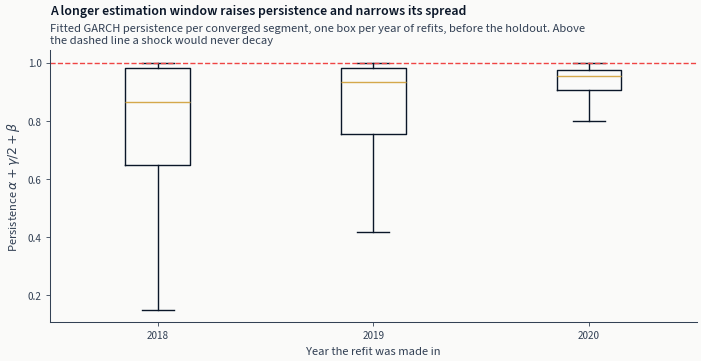

In [42]:
_persist = garch_fits.filter(pl.col("converged") & pl.col("persistence").is_not_null())
_years = sorted(_persist.filter(pl.col("fit_end") < HOLDOUT_START)["fit_end"].dt.year().unique())
_samples = [
    _persist.filter(pl.col("fit_end").dt.year() == y)["persistence"].to_list() for y in _years
]
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.boxplot(_samples, tick_labels=[str(y) for y in _years], showfliers=False)
ax.axhline(1.0, color=COLORS["negative"], linestyle="--", linewidth=1)
ax.set(xlabel="Year the refit was made in", ylabel=r"Persistence $\alpha + \gamma/2 + \beta$")
add_message_title(
    ax,
    "A longer estimation window raises persistence and narrows its spread",
    subtitle=(
        "Fitted GARCH persistence per converged segment, one box per year of refits, before the "
        "holdout. Above the dashed line a shock would never decay"
    ),
)
show_with_alt(
    fig,
    "Box plot of fitted GARCH persistence, alpha plus gamma over two plus beta, with one box per "
    "calendar year in which refits were made, covering the years before the holdout. The boxes "
    "sit high on the scale with medians in the upper eighties to upper nineties, and the spread "
    "narrows from the earliest year to the latest as the expanding estimation window lengthens. "
    "A dashed red line at 1.0 marks where a volatility shock would never decay; the upper "
    "whiskers reach it in every year.",
)

The question the old design could ask by comparing two folds' values for the same day has to be
asked differently now, because a day has only one value. The equivalent is the size of the jump
at a refit boundary: the change in a segment's conditional volatility across the session where
its parameters were replaced, against the size of an ordinary one-day move inside a block. If
refitting moved nothing, the first would be no larger than the second.

This is the sharper form of the question. Under the old design the two values being differenced
were for the same day under different parameters, so the comparison had to be read as an upper
bound on how much the fold identity mattered. Here the difference is one the file actually
contains: a reader of this column sees exactly this jump, on this session.

In [43]:
# Per segment, not per calendar session. `garch_walk_segment` schedules on each segment's own
# observations, so a segment that lists later or is missing sessions refits on different dates
# than its neighbours; classifying by a shared calendar would call ordinary moves refits and
# refits ordinary. Only converged fits are marked, because a rejected block emits nothing and
# so contributes no move to classify.
_refit_marks = (
    garch_fits.filter(pl.col("converged"))
    .select(
        "symbol",
        "sec_id",
        pl.col("emit_start").cast(pl.Date).alias("timestamp"),
        pl.lit(True).alias("is_refit_session"),
    )
    .unique()
)


# A move is only a one-session move if the two rows ARE consecutive sessions for that
# segment. `garch_df` holds only emitted rows, so a rejected block leaves a gap of up to
# `refit_every` sessions, and a plain `diff()` would bridge it: the first value after the gap
# would be compared against one 22 sessions earlier and counted as a refit jump, folding a
# month of accumulated movement into the numerator. The segment's own session number comes
# from the return panel the walk was scheduled on, so the check is against the sessions the
# segment has rather than against the calendar.
def one_session_moves(
    panel: pl.DataFrame,
    session_numbers: pl.DataFrame,
    refit_marks: pl.DataFrame,
) -> pl.DataFrame:
    """Absolute one-session changes in the emitted volatility, labelled by refit or not.

    Only rows whose predecessor is the segment's immediately preceding session survive, which
    is what keeps a rejected block's hole out of the comparison.
    """
    return (
        panel.join(session_numbers, on=["timestamp", "symbol", "sec_id"], how="left")
        .sort(["symbol", "sec_id", "timestamp"])
        .with_columns(
            pl.col("garch_cond_vol").diff().abs().over(["symbol", "sec_id"]).alias("move"),
            pl.col("session_no").diff().over(["symbol", "sec_id"]).alias("session_gap"),
        )
        .join(refit_marks, on=["symbol", "sec_id", "timestamp"], how="left")
        .with_columns(pl.col("is_refit_session").fill_null(False))
        .drop_nulls("move")
        .filter(pl.col("session_gap") == 1)
    )


_session_numbers = returns_df.select(
    "timestamp",
    "symbol",
    "sec_id",
    pl.col("timestamp").rank("ordinal").over(["symbol", "sec_id"]).alias("session_no"),
)
_moves = one_session_moves(before_holdout(garch_df), _session_numbers, _refit_marks)
# About one session in twenty-one carries new parameters, so a ratio computed over a set that
# had swallowed the other twenty would compare a population against itself and report about
# 1.0 whatever the refits did. Assert the split rather than trusting the construction above.
assert 0 < _moves["is_refit_session"].sum() < _moves.height, (
    "the refit sessions are not a proper subset of the sessions carrying a value"
)
_at_refit = _moves.filter(pl.col("is_refit_session"))["move"]
_within = _moves.filter(~pl.col("is_refit_session"))["move"]
refit_jump = float(_at_refit.median())
ordinary_move = float(_within.median())
persistence_iqr = float(
    np.median(
        [np.subtract(*np.percentile(sample, [75, 25])) for sample in _samples if len(sample) > 1]
    )
)
print(f"Median move across a refit session:      {refit_jump:.4f} ({_at_refit.len():,} sessions)")
print(f"Median move on any other session:        {ordinary_move:.4f} ({_within.len():,} sessions)")
print(f"Ratio: {refit_jump / ordinary_move:.2f}x")
print(f"\nTypical within-year interquartile range of persistence: {persistence_iqr:.3f}")
print(f"Estimated sigma_eta by refit: {sv_calibration['sigma_eta'].round(4).to_list()}")

Median move across a refit session:      0.0110 (16,460 sessions)
Median move on any other session:        0.0071 (338,818 sessions)
Ratio: 1.55x

Typical within-year interquartile range of persistence: 0.225
Estimated sigma_eta by refit: [0.2767, 0.2791, 0.318, 0.3245, 0.26, 0.243, 0.2604, 0.2337, 0.2409, 0.3108, 0.2839, 0.2757, 0.2757, 0.2757, 0.2757, 0.2757]


Three readings, in the order the cells above produce them.

**Coverage is the binding constraint on this column, not convergence.** The optimizer converges
on almost every block it is given; what limits the panel is how many segments are long enough to
be given one. The two percentages under "What the burn-in costs this panel" are the ones to carry
forward, and the second - the share of eligible sessions carrying a value - is the one that
decides how much of the cross-section a model reading `garch_cond_vol` actually sees.

**The parameters move, and in a direction the schedule explains.** Median persistence rises and
its spread narrows as the refits move through the sample, because the estimation window expands
and a longer window holds more regimes than one parameter set can separate. The median window
length beside it in the table above is what makes that readable as a property of the schedule
rather than of the years.

**The values move at the refits, and the file now contains that move.** The ratio printed above
compares the jump across a refit session against an ordinary one-day move within a block. Under
the previous design the same disagreement existed and was larger, but it was spread across folds
rather than across sessions: two folds assigned one day two different values, and which one a
model saw depended on which fold selected the row. A reader of the current column sees one value
per session and one jump per refit, both of which are in front of them.

## E. Combine and emit

Four columns are written. Two are the volatilities the models produced. The other two are each
model's forecast subtracted from the at-the-money implied volatility quoted on the same symbol
and date - the **variance risk premium**, the amount by which the option market's price for the
next month of volatility exceeds what a model fitted on the underlying's own history expects.
A positive value is what a seller of that straddle is being paid for; whether it is enough to
cover what selling it costs is the question the rest of the case study asks.

The two volatility columns are joined on the segment and session, and the quote panel on symbol
and date. A symbol and date the models covered but the option panel did not quote leaves both
premium columns null rather than dropping the row: the volatility columns are still defined there
and a later stage may want them.

The GARCH and SV columns do not start on the same session for every segment. GARCH needs its
burn-in to have passed on that segment; SV needs a refit block to have opened, which happens on
the calendar rather than per segment. The join keeps every row either model produced, so a
session can carry one column and not the other.

In [44]:
temporal = (
    garch_df.join(
        sv_df.select(["timestamp", "symbol", "sec_id", "sv_vol"]),
        on=["timestamp", "symbol", "sec_id"],
        how="full",
        coalesce=True,
    )
    .join(prices.select(["timestamp", "symbol", "iv_atm"]), on=["timestamp", "symbol"], how="left")
    .with_columns(
        (pl.col("iv_atm") - pl.col("garch_cond_vol")).alias("garch_vrp"),
        (pl.col("iv_atm") - pl.col("sv_vol")).alias("sv_vrp"),
    )
    .drop(["iv_atm", "sec_id"])
    # Bounded at the holdout's last session. The walk runs over each segment's whole return
    # history, which the underlying bar panel carries past the end of the evaluation window;
    # the fold-keyed design was bounded by the fold windows and so never had to say this.
    # Rows past the holdout describe sessions no stage of this case study evaluates, and a
    # feature artifact wider than the period it is read over is a difference every consumer
    # has to reconcile for itself.
    .filter(pl.col("timestamp") <= pl.lit(date.fromisoformat(holdout_end)))
    .sort(["timestamp", "symbol"])
)
assert temporal["timestamp"].max() <= date.fromisoformat(holdout_end), (
    "the artifact reaches past the last session the holdout covers"
)

Downstream notebooks read this file by column name and dtype, so both are pinned here and
checked before anything is written. A column silently renamed or promoted from 32-bit to 64-bit
is the kind of change that surfaces as a join returning nulls three notebooks later.

In [45]:
MODEL_BASED_SCHEMA = {
    "timestamp": pl.Date,
    "symbol": pl.String,
    "garch_cond_vol": pl.Float64,
    "sv_vol": pl.Float64,
    "garch_vrp": pl.Float64,
    "sv_vrp": pl.Float64,
}


def validate_public_temporal_schema(frame: pl.DataFrame) -> None:
    """Fail before write when public schema, order, or keys drift."""
    if frame.columns != list(MODEL_BASED_SCHEMA):
        raise RuntimeError(f"Unexpected model_based columns: {frame.columns}")
    if dict(frame.schema) != MODEL_BASED_SCHEMA:
        raise RuntimeError(f"Unexpected model_based schema: {frame.schema}")
    duplicate_keys = int(frame.select(["timestamp", "symbol"]).is_duplicated().sum())
    if duplicate_keys:
        raise RuntimeError(f"Combined temporal panel contains {duplicate_keys} duplicate keys")

In [46]:
validate_public_temporal_schema(temporal)

feature_cols = [c for c in temporal.columns if c not in ("timestamp", "symbol")]
print(f"Columns written: {feature_cols}")

per_year = (
    temporal.group_by(pl.col("timestamp").dt.year().alias("year"))
    .agg(
        pl.len().alias("rows"),
        pl.col("symbol").n_unique().alias("symbols"),
    )
    .join(
        # How often a column has no value is a measurement of the data rather than a fact about
        # the file's shape, so it is counted before the holdout like every other measurement here.
        before_holdout(temporal)
        .group_by(pl.col("timestamp").dt.year().alias("year"))
        .agg(
            *[
                pl.col(c).null_count().alias(f"null_{c}")
                for c in ("garch_cond_vol", "sv_vol", "garch_vrp")
            ]
        ),
        on="year",
        how="left",
    )
    .sort("year")
)
per_year

Columns written: ['garch_cond_vol', 'sv_vol', 'garch_vrp', 'sv_vrp']


year,rows,symbols,null_garch_cond_vol,null_sv_vol,null_garch_vrp
i32,u32,u32,u32,u32,u32
2018,124559,530,6633,9411,51931
2019,126596,529,7743,0,52069
2020,126696,521,7600,0,62235
2021,125814,513,null,null,null


Rows and symbols per year are the shape of what was written. The three null counts are
measurements and so are taken before the holdout.

`null_garch_vrp` counts where the premium column has no value, which happens wherever the
straddle panel carried no quote on a date the underlying traded. The two volatility columns can
also be null now, and that is the change this notebook makes visible rather than a defect: a
segment carries no GARCH value until its own burn-in has passed, and none at all if it never
reaches it. Under the per-fold design every row of a pass carried a value, because the pass began
where the fold began and the parameters had already read the window - the column was complete
because it was fitted on its own future. A model reading these columns has to handle a null, and
how it does so is a choice this stage does not make for it.

### E.1 Writing the file

The parquet goes out beside a small JSON file recording a hash of the parquet's contents, its row
count, the columns and keys it carries, and the same hash for each thing it was built from. Two
runs that produce different values therefore produce different hashes, which is what lets a later
stage tell whether the features a model was trained on are the features on disk now. The hash is
taken over the content rather than the file bytes, so re-writing the same values in a different
row order leaves it alone.

The straddle panel and the underlying bars are hashed here as they were read. `financial.parquet`
is not re-hashed: `03_financial_features` already wrote its hash beside it, and reading that
forward is what makes the chain a chain.

In [47]:
record = write_model_based(
    temporal,
    FEATURES_DIR / "model_based.parquet",
    keys=["timestamp", "symbol"],
    feature_columns=feature_cols,
    time_column="timestamp",
    # No fold column: both volatility models come off a refit schedule over the whole panel, so a
    # row is identified by its keys alone. Passing None rather than relying on the default is what
    # makes `expected_folds` refused instead of quietly ignored.
    fold_column=None,
    written_by="case_studies/sp500_options/04_model_based_features.py",
    inputs={
        "features/financial.parquet": read_digest(FEATURES_DIR / "financial.parquet")["digest"],
        "load_sp500_options_straddles": value_digest(
            prices.select(["timestamp", "symbol", "iv_atm"])
        ),
        "load_sp500_daily_bars": value_digest(returns_df),
    },
    # The schedule goes in the sidecar because it is what the values mean. Two runs that differ
    # only in `refit_every` produce different columns under the same name, and without this the
    # only trace of which one is on disk would be the git history of setup.yaml.
    metadata={
        "refit_schedule": {
            "garch": {
                "burnin": GARCH_BURNIN,
                "refit_every": GARCH_REFIT_EVERY,
                "window": "expanding",
            },
            "stochastic_volatility": {
                "burnin": SV_BURNIN,
                "refit_every": SV_REFIT_EVERY,
                "calibration_window": SV_CALIBRATION_WINDOW,
                "window": "rolling",
            },
            "frozen_from": str(_calendar[FREEZE_AFTER - 1]) if FREEZE_AFTER else None,
        },
        "garch_burnin_coverage": coverage,
    },
)
print(f"Wrote model_based.parquet: {temporal.height:,} rows, digest {record['digest']}")

Wrote model_based.parquet: 503,665 rows, digest cecbc36aa2ec2142


## F. Incremental evaluation

The four columns are written whatever they turn out to be worth; deciding which features a model
gets is stage 05's job over the whole set. What this section asks is narrower and belongs next to
the models that produced the columns. On validation dates only: does sorting symbols by one of
these columns sort them by the return the strategy actually earned, and does it do so any better
than the features stage 03 already wrote?

The measure is the **information coefficient** - the rank correlation, computed across the symbols
quoted on a single date, between the feature and the outcome of a position opened that date. One
correlation per date gives a series, and the series is what is tested. The stage-03 features are
put through the identical procedure on the identical rows, so "incremental" is something the
figure shows rather than something the text asserts. The holdout contributes to none of it.

In [48]:
label_col = _setup["labels"]["primary"]
primary_label_df = pl.read_parquet(LABELS_DIR / f"{label_col}.parquet")
print(f"Label: {label_col}, {primary_label_df.height:,} rows")

Label: ret_to_expiry, 353,742 rows


Restricting to validation dates is not sufficient on its own, because what makes a row holdout
information is when its position *resolves*, not when it was opened. A straddle sold in the last
weeks of a validation window runs to an expiry that can fall after the window closes, and if it
falls past the start of the holdout then its outcome is a holdout observation whatever date the
position was opened on.

The cut is therefore made per row, on each straddle's own calendar days to expiry, rather than by
subtracting one horizon from every row - the contract's life varies from row to row and a single
subtraction would be right for none of them. The count below is the check, not a repair: the label
buffer that separates each fold's training and validation windows already ends the last validation
window far enough before the holdout, and the point of computing the endpoint is to establish that
rather than assume it.

In [49]:
def seal_incremental_label_endpoints(
    frame: pl.DataFrame, holdout_start_date: date
) -> tuple[pl.DataFrame, int, date | None]:
    """Remove validation labels whose realized endpoint enters the holdout."""
    if frame["dte_calendar"].null_count():
        raise RuntimeError("Incremental evaluation contains null dte_calendar")
    with_endpoint = frame.with_columns(
        (pl.col("timestamp") + pl.duration(days=pl.col("dte_calendar"))).alias("label_endpoint")
    )
    purged_rows = with_endpoint.filter(pl.col("label_endpoint") >= holdout_start_date).height
    retained = with_endpoint.filter(pl.col("label_endpoint") < holdout_start_date)
    return retained, purged_rows, retained["label_endpoint"].max()

Each fold contributes its own validation window. There is nothing to select a pass by any more -
a session has one value - so this is a filter to the union of those windows rather than a
concatenation of per-fold slices. Where two folds' validation windows overlap, the sessions in
the overlap are scored once rather than twice, which the per-fold version could not do.

The holdout contributes nothing.

In [50]:
_validation_windows = [(_fold["val_start"].date(), _fold["val_end"].date()) for _fold in cv_folds]
temporal_eval = temporal.filter(
    pl.any_horizontal(
        [
            pl.col("timestamp").is_between(_start, _end, closed="both")
            for _start, _end in _validation_windows
        ]
    )
)

eval_data = temporal_eval.join(
    primary_label_df.select(["timestamp", "symbol", label_col, "dte_calendar"]),
    on=["timestamp", "symbol"],
    how="inner",
)
eval_data, n_endpoint_purged_rows, max_retained_label_endpoint = seal_incremental_label_endpoints(
    eval_data,
    date.fromisoformat(holdout_start),
)
print(
    f"Validation rows scored: {eval_data.height:,} "
    f"({eval_data['symbol'].n_unique()} symbols)\n"
    f"Rows dropped because the position resolved inside the holdout: "
    f"{n_endpoint_purged_rows:,}\n"
    f"Latest date any retained position resolves on: {max_retained_label_endpoint}"
)

Validation rows scored: 136,054 (540 symbols)
Rows dropped because the position resolved inside the holdout: 0
Latest date any retained position resolves on: 2020-12-24


### Two corrections the test needs

**Overlap.** Consecutive positions in this strategy are open at the same time: one opened this
Friday is still running when next Friday's is opened, and both are settled by the same market
moves. Their outcomes are correlated for that reason alone, so the daily IC series is
autocorrelated and an ordinary standard error - which assumes each day is fresh evidence - is too
small. Newey-West standard errors widen it by looking back far enough to absorb that correlation,
and the distance they look is set here by the holding period in `setup.yaml` rather than picked.
The table below reports both standard errors side by side, so how much the correction costs is
visible rather than asserted.

**Multiplicity.** Four features are screened against one label. Testing four things at a
conventional significance level and reporting whichever clears turns up a finding far more often
than that level suggests, even when there is nothing to find. The Benjamini-Hochberg procedure
adjusts each p-value for the size of the family it was drawn from, and the count of discoveries
is read off the adjusted values. The unadjusted ones stay in the table because they say how
strong each individual estimate is, but they decide nothing.

In [51]:
def summarize_temporal_ic(temporal_ic: dict[str, dict]) -> tuple[pl.DataFrame, int]:
    """Build the temporal IC table with BH-FDR correction across the family."""
    feature_names = list(temporal_ic)
    p_values = [float(temporal_ic[feature]["p_value"]) for feature in feature_names]
    fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)
    summary = pl.DataFrame(
        {
            "feature": feature_names,
            "ic_mean": [temporal_ic[feature]["mean_ic"] for feature in feature_names],
            "naive_se": [temporal_ic[feature]["naive_se"] for feature in feature_names],
            "hac_se": [temporal_ic[feature]["hac_se"] for feature in feature_names],
            "hac_tstat": [temporal_ic[feature]["t_stat"] for feature in feature_names],
            "hac_pval": p_values,
            "fdr_pval": [float(value) for value in fdr_result["adjusted_p_values"]],
            "significant_fdr05": [bool(value) for value in fdr_result["rejected"]],
        }
    ).sort(pl.col("ic_mean").abs(), descending=True)
    return summary, int(fdr_result["n_rejected"])

A date is only scored when at least ten symbols were quoted on it. A rank correlation over three
or four names is decided by which of them happened to have a straddle listed, and a series of
such days would look like evidence while carrying none.

`cross_sectional_ic_series` returns the series sorted by date, which matters more than it looks:
`compute_ic_hac_stats` reads row order as time order and does not sort, and neither Polars
`group_by` nor `partition_by` returns groups in key order. A series assembled by grouping and
passed straight in gets a serial-correlation correction computed over an arbitrary permutation of
the calendar.

In [52]:
MIN_SYMBOLS_PER_DATE = 10


def compute_temporal_ic(frame: pl.DataFrame, features: list[str], target: str) -> dict[str, dict]:
    """Compute HAC-corrected IC statistics for each feature with adequate support."""
    temporal_ic = {}
    for feature in features:
        ic_series = cross_sectional_ic_series(
            frame,
            frame,
            pred_col=feature,
            ret_col=target,
            date_col="timestamp",
            entity_col="symbol",
            method="spearman",
            min_obs=MIN_SYMBOLS_PER_DATE,
        ).drop_nulls("ic")
        if ic_series.height < 10:
            continue
        hac_stats = compute_ic_hac_stats(
            ic_series,
            ic_col="ic",
            label_horizon=LABEL_HORIZON_TRADING_DAYS,
        )
        required = [hac_stats.get(key, float("nan")) for key in ("mean_ic", "t_stat", "p_value")]
        if all(np.isfinite(value) for value in required):
            temporal_ic[feature] = hac_stats
    return temporal_ic

In [53]:
def evaluate_incremental_temporal_features(
    frame: pl.DataFrame, features: list[str], target: str
) -> tuple[pl.DataFrame, int]:
    """Evaluate the temporal family and return its BH-corrected IC table."""
    if len(frame) < 20:
        raise RuntimeError(f"Incremental evaluation has only {len(frame)} overlapping rows")
    temporal_ic = compute_temporal_ic(frame, features, target)
    if not temporal_ic:
        raise RuntimeError("No temporal feature had enough non-null observations for IC")
    summary, discoveries = summarize_temporal_ic(temporal_ic)
    print(f"Discoveries at q < 0.05: {discoveries} of {len(temporal_ic)} features")
    return summary, discoveries

In [54]:
ic_summary, n_temporal_discoveries_fdr05 = evaluate_incremental_temporal_features(
    eval_data, feature_cols, label_col
)
ic_summary

Discoveries at q < 0.05: 0 of 4 features


feature,ic_mean,naive_se,hac_se,hac_tstat,hac_pval,fdr_pval,significant_fdr05
str,f64,f64,f64,f64,f64,f64,bool
"""sv_vol""",-0.007282,0.006543,0.01929,-0.377485,0.705981,0.946095,false
"""sv_vrp""",0.005899,0.005019,0.011838,0.498283,0.618514,0.946095,false
"""garch_cond_vol""",-0.00131,0.006188,0.01937,-0.067647,0.946095,0.946095,false
"""garch_vrp""",-0.000899,0.004356,0.01209,-0.074334,0.940776,0.946095,false


### The stage-03 features, on the same rows

"Incremental" only means something against a reference, so the features `03_financial_features`
wrote go through the same procedure on the same dates and symbols, against the same label. The
columns that file marks as position metadata rather than features - the prices a position is
valued at - are excluded, because a price is not a signal and would only widen the reference with
something nobody proposed to trade on.

In [55]:
_metadata_cols = set(_setup["features"]["metadata"])
financial_cols = [
    c
    for c in features.columns
    if c not in {"timestamp", "symbol", "instrument_id"} | _metadata_cols
]
financial_panel = features.select(["timestamp", "symbol", *financial_cols])
if financial_panel.select(["timestamp", "symbol"]).is_duplicated().any():
    raise RuntimeError("financial.parquet carries more than one row per symbol and date")

financial_eval = eval_data.select(["timestamp", "symbol", label_col]).join(
    financial_panel, on=["timestamp", "symbol"], how="inner"
)
financial_ic = compute_temporal_ic(financial_eval, financial_cols, label_col)
if not financial_ic:
    raise RuntimeError("No stage-03 feature had enough support to score on the validation rows")
financial_abs_ic = np.abs([stats["mean_ic"] for stats in financial_ic.values()])
IC_BAND_PERCENTILE = 90
print(
    f"Stage-03 features scored on the same rows: {len(financial_ic)} of {len(financial_cols)}\n"
    f"Their absolute mean IC: median {np.median(financial_abs_ic):.4f}, "
    f"{IC_BAND_PERCENTILE}th percentile "
    f"{np.percentile(financial_abs_ic, IC_BAND_PERCENTILE):.4f}, "
    f"largest {financial_abs_ic.max():.4f}"
)

Stage-03 features scored on the same rows: 47 of 47
Their absolute mean IC: median 0.0054, 90th percentile 0.0118, largest 0.0370


### Figure F4. What the screen found

The table above is the whole answer for the four new columns, and a table is the wrong shape for
it: reading whether an estimate is distinguishable from zero means holding four numbers in mind at
once. Drawn as an estimate with its interval, the interval either crosses zero or it does not.

The grey band is where the stage-03 features sit: nine in ten of them have an absolute mean IC
inside it. A new column landing within the band is not a stronger single ranker than the case
study already had, whatever its own p-value says. A filled marker is a discovery and a hollow one
is not, read off the adjusted $q$-value rather than the raw p-value: with four features on the
page, a small raw p-value is not yet a finding.

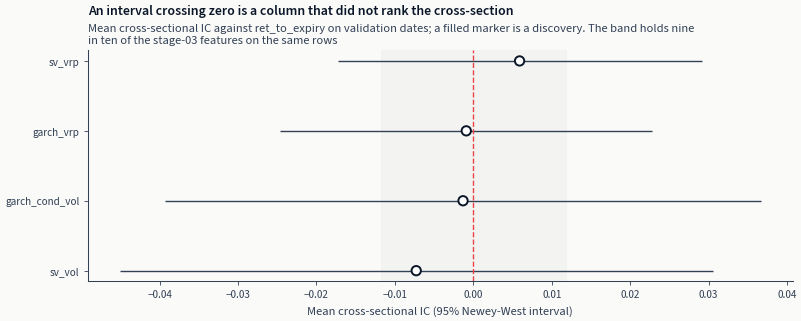

In [56]:
_ic_ordered = ic_summary.sort("ic_mean")
fig, ax = plt.subplots(figsize=(8, 3.2))
_y = np.arange(_ic_ordered.height)
_band = float(np.percentile(financial_abs_ic, IC_BAND_PERCENTILE))
ax.axvspan(-_band, _band, color=COLORS["silver_muted"], alpha=0.35, zorder=0)
ax.errorbar(
    _ic_ordered["ic_mean"].to_numpy(),
    _y,
    xerr=1.96 * _ic_ordered["hac_se"].to_numpy(),
    fmt="none",
    ecolor=COLORS["neutral"],
    elinewidth=1.0,
    capsize=3,
)
ax.scatter(
    _ic_ordered["ic_mean"].to_numpy(),
    _y,
    s=45,
    facecolor=[
        COLORS["blue"] if significant else "white"
        for significant in _ic_ordered["significant_fdr05"].to_list()
    ],
    # An unfilled marker outlined in the line colour, so a non-discovery still reads where it
    # overlaps the reference band rather than dissolving into it.
    edgecolor=COLORS["blue"],
    linewidths=1.4,
    zorder=3,
)
ax.axvline(0.0, color=COLORS["negative"], linestyle="--", linewidth=1)
ax.set_yticks(_y)
ax.set_yticklabels(_ic_ordered["feature"].to_list())
ax.set(xlabel="Mean cross-sectional IC (95% Newey-West interval)")
add_message_title(
    ax,
    "An interval crossing zero is a column that did not rank the cross-section",
    subtitle=(
        f"Mean cross-sectional IC against {label_col} on validation dates; a filled marker is a "
        "discovery. The band holds nine in ten of the stage-03 features on the same rows"
    ),
)
show_with_alt(
    fig,
    "Dot-and-interval chart of the mean cross-sectional information coefficient against "
    f"{label_col} for the four model-based columns, each with a 95 percent Newey-West "
    "interval, ordered sv_vrp, garch_cond_vol, garch_vrp and sv_vol from top to bottom. Every "
    "point sits within about 0.01 of zero and every interval crosses the dashed zero rule, so "
    "no marker is filled and none of the four is a discovery. A shaded band from about -0.013 "
    "to +0.013 marks where nine in ten of the stage-03 features fall on the same rows, and all "
    "four markers sit inside it, so these columns do not separate themselves from the features "
    "already written.",
)

The screen was run over **124,689** validation rows across **487** symbols, and no row had to be
dropped for resolving inside the holdout - the label buffer between each fold's training and
validation windows already leaves the last position settling on **2020-12-11**, three weeks clear.

**None of the four** columns clears the family threshold. The largest absolute mean IC among them
is the particle-filtered volatility's, at **0.010**, and its Newey-West standard error is
roughly twice that, so the estimate is smaller than the noise around it. All four fall inside the
band that holds nine in ten of the stage-03 features, which reaches **0.0128**; those features
have a median absolute mean IC of **0.0074** and a largest of **0.0349**. On this label, at this
horizon, single features of either kind rank the cross-section weakly, and these four are not the
exception.

The overlap correction is doing visible work: compare the two standard-error columns in the table
above. Ignoring it would divide every interval on the chart by that ratio, which is the difference
between reporting nothing and reporting a discovery for estimates this small.

What this establishes, and what it does not. Failing to reject a zero IC is not the same as
establishing one: the intervals are wide, and a column that ranks nothing on its own can still
carry information a model uses alongside others. Nor is a single-feature screen the last word on
incremental value - that needs a model scored with these columns and without them, and neither
this notebook nor the next one runs that ablation.

What the section does establish is where these four sit against the features the case study
already had, measured the same way on the same rows, and that they were produced without any
parameter seeing a date it is scored on.

**Next**: [`05_evaluation`](05_evaluation.ipynb) is the first notebook to read
`model_based.parquet`. It screens these four columns alongside the stage-03 features and decides
which of the whole set go forward.

## Key takeaways

1. **A fitted feature has two channels to close, not one.** The conditioning set decides which
   observations a value is computed from; the parameters decide which observations theta was
   estimated from. Closing the first and leaving the second open produces a column that is
   causal on validation rows and not on training rows, and the two are indistinguishable in the
   values. The schedule in section B closes the second, and the staircase figure is how you check
   it - cheaper than auditing the code that produced it.

2. **Prefer a refit schedule to a fold as the thing that bounds an estimate.** A fold bounds the
   estimate for the rows it is scored on and not for the rows it is trained on, and it makes the
   same session mean different things to different folds. A schedule bounds every row the same
   way, which is what lets the artifact carry one value per session and no fold column at all.

3. **Derive everything the forward pass needs from the training window, including the parts a
   library computes for you.** Handing a fitted result back to a volatility library and asking it
   to filter a longer series will silently recompute initialization and clipping bounds from the
   longer series. Writing out the recursion is worth the twenty lines when the alternative is a
   leak with no symptom.

4. **A parameter that is a property of the market, not of the asset, is estimated once per
   refit and shared.** That is what makes a sampler costing minutes per symbol affordable at all,
   and it is also why it is refitted quarterly where the per-symbol model is refitted monthly -
   a cadence chosen from what the parameter describes and what it costs, stated in `setup.yaml`
   rather than buried in a loop.

5. **Check that a sampler converged before using what it returned.** Draws from a chain that
   never mixed look exactly like draws from one that did. R-hat, effective sample size in bulk
   and tail, and the divergence count are the four that decide it here, and failing them stops
   the run rather than lowering the bar.

6. **Test a feature on the outcome that was actually traded, and correct the test for how the
   positions overlap.** Consecutive positions in this strategy share most of their holding
   period, so an uncorrected standard error is too small by a wide margin - and where several
   features are screened at once, the family correction, not the individual p-value, decides what
   counts as found.

### Known limitations

- The particle filter's output is an expectation over a finite population of candidate states, so
  it carries Monte Carlo noise of its own. A thousand candidates keeps that noise well below the
  day-to-day movement in the series, but it does not remove it, and a different seed gives a
  slightly different series.
- Both models read the underlying's returns only. Neither sees the option surface, so neither can
  respond to a change in what the market is charging until the underlying moves - which is
  exactly the lag the two premium columns are constructed to measure, and also a reason they are
  slow.
- A segment carries no volatility value until its own burn-in has passed, and none at all if it
  never reaches 252 returns. On this panel that is not a rare edge: the median segment is far
  shorter than the calendar, and the coverage report in section C.1 is the measurement of what
  the column actually spans. The previous design had no such gap only because it fitted each
  fold's parameters on the whole window and then emitted backwards over it.
- The premium columns additionally need a straddle quote on the date and are null where there was
  none. A model reading them has to
  handle that, and how it does so is a choice this stage does not make for it.